In [1]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Μόνιμα αρχεία (splits, checkpoints, results) στο Drive
PROJECT_DIR = Path("/content/drive/MyDrive/EuroSAT_DL_Assignment")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

ART_DIR = PROJECT_DIR / "artifacts"
ART_DIR.mkdir(parents=True, exist_ok=True)

SPLITS_PATH = ART_DIR / "splits_seed42.npz"

# Dataset τοπικά (γρήγορο I/O για training)
DATA_ROOT = Path("/content/eurosat_data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR (Drive):", PROJECT_DIR)
print("ART_DIR (Drive):", ART_DIR)
print("SPLITS_PATH (Drive):", SPLITS_PATH)
print("DATA_ROOT (LOCAL):", DATA_ROOT)


Mounted at /content/drive
PROJECT_DIR (Drive): /content/drive/MyDrive/EuroSAT_DL_Assignment
ART_DIR (Drive): /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts
SPLITS_PATH (Drive): /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/splits_seed42.npz
DATA_ROOT (LOCAL): /content/eurosat_data


In [2]:
# Imports, seed, and device setup

import os, time, random


import numpy as np


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms


import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


from tqdm.auto import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("DATA_ROOT:", DATA_ROOT)


device: cuda
torch: 2.9.0+cu126
torchvision: 0.24.0+cu126
DATA_ROOT: /content/eurosat_data


100%|██████████| 94.3M/94.3M [00:00<00:00, 537MB/s]


N images: 27000
N classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Sample type: <class 'PIL.Image.Image'>
Image size: (64, 64)
Label id: 0 -> class name: AnnualCrop


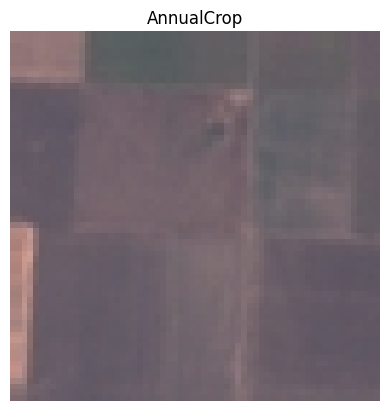

In [3]:
# Load EuroSAT dataset + sample
from torchvision.datasets import EuroSAT

ds = EuroSAT(root=str(DATA_ROOT), download=True)

print("N images:", len(ds))
print("N classes:", len(ds.classes))
print("Classes:", ds.classes)

img, y0 = ds[0]
print("Sample type:", type(img))
print("Image size:", img.size)
print("Label id:", y0, "-> class name:", ds.classes[y0])

plt.imshow(img)
plt.title(ds.classes[y0])
plt.axis("off")
plt.show()


In [4]:
# Stratified splits with caching (no leakage)
SEED = 42


y_now = np.array(ds.targets) if hasattr(ds, "targets") else np.array([ds[i][1] for i in range(len(ds))])

need_recompute = True

if SPLITS_PATH.exists():
    data = np.load(SPLITS_PATH)
    y_saved = data["y"]

    if np.array_equal(y_saved, y_now):
        train_idx = data["train_idx"]
        val_idx   = data["val_idx"]
        test_idx  = data["test_idx"]
        y         = y_saved
        need_recompute = False
        print(" Loaded splits (match dataset order):", SPLITS_PATH)
    else:
        print(" Splits file exists BUT does NOT match current dataset order -> recompute once.")

if need_recompute:
    indices = np.arange(len(ds))
    y = y_now

    train_idx, temp_idx = train_test_split(
        indices, train_size=0.7, random_state=SEED, stratify=y
    )
    y_temp = y[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, random_state=SEED, stratify=y_temp
    )

    np.savez_compressed(
        SPLITS_PATH,
        train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
        y=y, seed=np.array(SEED)
    )
    print("Recomputed + saved splits to:", SPLITS_PATH)

print("lens:", len(train_idx), len(val_idx), len(test_idx))


 Loaded splits (match dataset order): /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/splits_seed42.npz
lens: 18900 4050 4050


In [5]:
# Class distribution per split
def counts_for(idx):
    y_split = y[idx]
    counts = np.bincount(y_split, minlength=len(ds.classes))
    return {ds.classes[i]: int(counts[i]) for i in range(len(ds.classes))}

print("Train:", counts_for(train_idx))
print("Val:  ", counts_for(val_idx))
print("Test: ", counts_for(test_idx))


Train: {'AnnualCrop': 2100, 'Forest': 2100, 'HerbaceousVegetation': 2100, 'Highway': 1750, 'Industrial': 1750, 'Pasture': 1400, 'PermanentCrop': 1750, 'Residential': 2100, 'River': 1750, 'SeaLake': 2100}
Val:   {'AnnualCrop': 450, 'Forest': 450, 'HerbaceousVegetation': 450, 'Highway': 375, 'Industrial': 375, 'Pasture': 300, 'PermanentCrop': 375, 'Residential': 450, 'River': 375, 'SeaLake': 450}
Test:  {'AnnualCrop': 450, 'Forest': 450, 'HerbaceousVegetation': 450, 'Highway': 375, 'Industrial': 375, 'Pasture': 300, 'PermanentCrop': 375, 'Residential': 450, 'River': 375, 'SeaLake': 450}


<!-- MD_Q0_1 -->
### Q0.1 Splits & leakage

- Έφτιαξα **stratified** splits με seed **42** σε αναλογία **70% / 15% / 15%**:
  - **Train (full): 18,900** εικόνες
  - **Validation: 4,050** εικόνες
  - **Test: 4,050** εικόνες
- **Ανά κλάση** (stratified, ίδιο ποσοστό ανά class):

| Class | Total | Train (70%) | Val (15%) | Test (15%) |
|---|---:|---:|---:|---:|
| AnnualCrop | 3000 | 2100 | 450 | 450 |
| Forest | 3000 | 2100 | 450 | 450 |
| Residential | 3000 | 2100 | 450 | 450 |
| SeaLake | 3000 | 2100 | 450 | 450 |
| HerbaceousVegetation | 2500 | 1750 | 375 | 375 |
| Highway | 2500 | 1750 | 375 | 375 |
| Industrial | 2500 | 1750 | 375 | 375 |
| Pasture | 2500 | 1750 | 375 | 375 |
| PermanentCrop | 2500 | 1750 | 375 | 375 |
| River | 2500 | 1750 | 375 | 375 |

- Έφτιαξα επίσης δύο few-shot train sets **ΜΟΝΟ από το train split** (ώστε να μην υπάρχει leakage):
  - **10-shot:** 10 δείγματα/κλάση → **100** εικόνες συνολικά
  - **5-shot:** 5 δείγματα/κλάση → **50** εικόνες συνολικά
- **Leakage prevention:** τα sets είναι **αμοιβαία ξένα** (train/val/test indices disjoint), και το **test** χρησιμοποιείται μόνο για **τελικό reporting** (όχι για επιλογή μοντέλου/ρυθμίσεων).


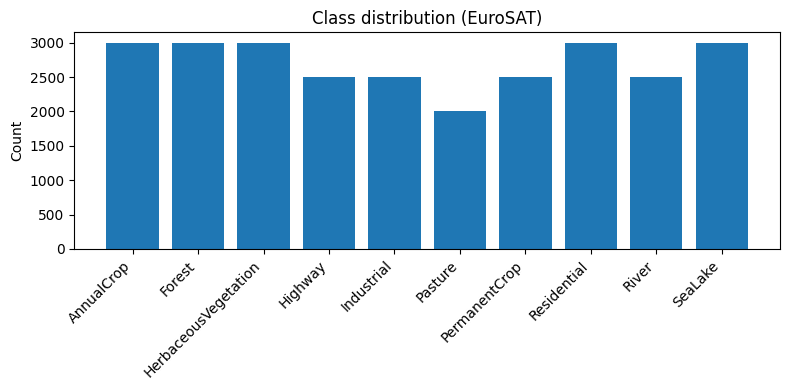

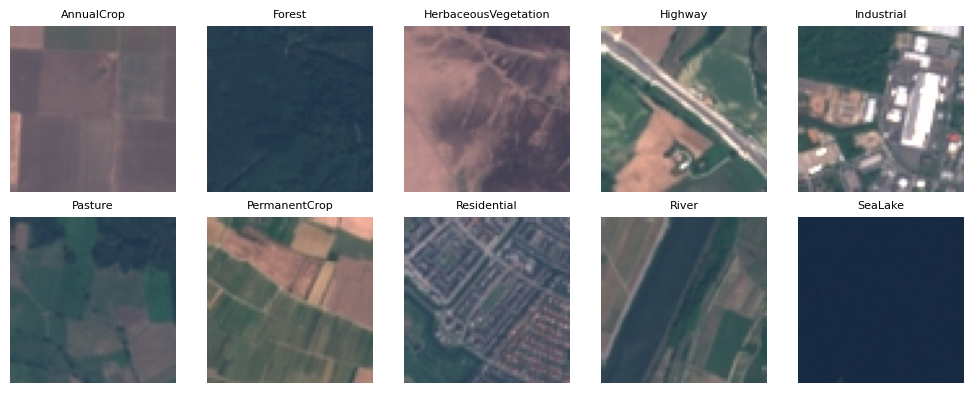

In [6]:
# Visualisations: distribution + samples per class
import numpy as np
import matplotlib.pyplot as plt

y_all = np.array(ds.targets) if hasattr(ds, "targets") else np.array([ds[i][1] for i in range(len(ds))])
counts = np.bincount(y_all, minlength=len(ds.classes))

plt.figure(figsize=(8,4))
plt.bar(ds.classes, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Class distribution (EuroSAT)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
for c, name in enumerate(ds.classes):
    idx = int(np.where(y_all == c)[0][0])
    img, _ = ds[idx]
    plt.subplot(2, 5, c+1)
    plt.imshow(img)
    plt.title(name, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [7]:
# Transforms (64x64) and data loaders
from torchvision.datasets import EuroSAT

BATCH_SIZE = 64

train_tf_64 = transforms.Compose([
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
])

eval_tf_64 = transforms.Compose([
    transforms.ToTensor(),
])


ds_train = EuroSAT(root=str(DATA_ROOT), download=True, transform=train_tf_64)
ds_eval  = EuroSAT(root=str(DATA_ROOT), download=True, transform=eval_tf_64)

train_set = Subset(ds_train, train_idx)
val_set   = Subset(ds_eval,  val_idx)
test_set  = Subset(ds_eval,  test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("xb:", xb.shape, xb.dtype)
print("yb:", yb.shape, yb.dtype)


xb: torch.Size([64, 3, 64, 64]) torch.float32
yb: torch.Size([64]) torch.int64


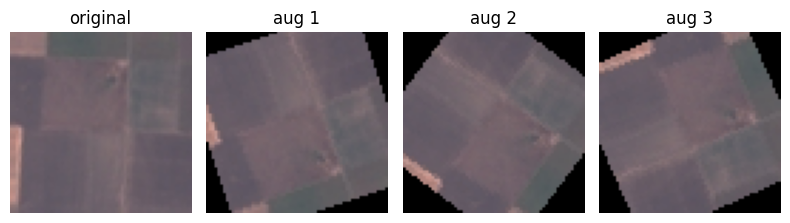

In [8]:
# Augmentation examples (original vs augmented)
import matplotlib.pyplot as plt

idx = 0
img, label = ds[idx]

plt.figure(figsize=(8,2.5))
plt.subplot(1,4,1)
plt.imshow(img)
plt.title("original")
plt.axis("off")

for i in range(3):
    aug = train_tf_64(img)
    aug_img = aug.permute(1,2,0).numpy()
    plt.subplot(1,4,i+2)
    plt.imshow(aug_img)
    plt.title(f"aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


<!-- MD_Q0_2 -->
### Q0.2 Augmentations

- Για το baseline στα **64×64** χρησιμοποίησα augmentations που “στέκουν” σε δορυφορικές εικόνες:
  - **RandomVerticalFlip(p=0.5)** (η κατεύθυνση/προσανατολισμός δεν είναι πάντα σημασιολογικός)
  - **RandomRotation(90°)** (ισοδυναμία προσανατολισμού σε aerial imagery)
- Για τα pretrained μοντέλα στα **224×224** χρησιμοποίησα:
  - **Resize(256) + RandomResizedCrop(224, scale=(0.8, 1.0))** (robustness σε κλίμακα/μετατόπιση)
  - **RandomHorizontalFlip(p=0.5) + RandomVerticalFlip(p=0.5)**
  - **Normalize(ImageNet mean/std)** για συμβατότητα με ImageNet-pretrained weights
- Για **validation/test**: **χωρίς augmentation** (μόνο deterministic resize/center crop + normalize), ώστε η αξιολόγηση να είναι **σταθερή και δίκαιη**.


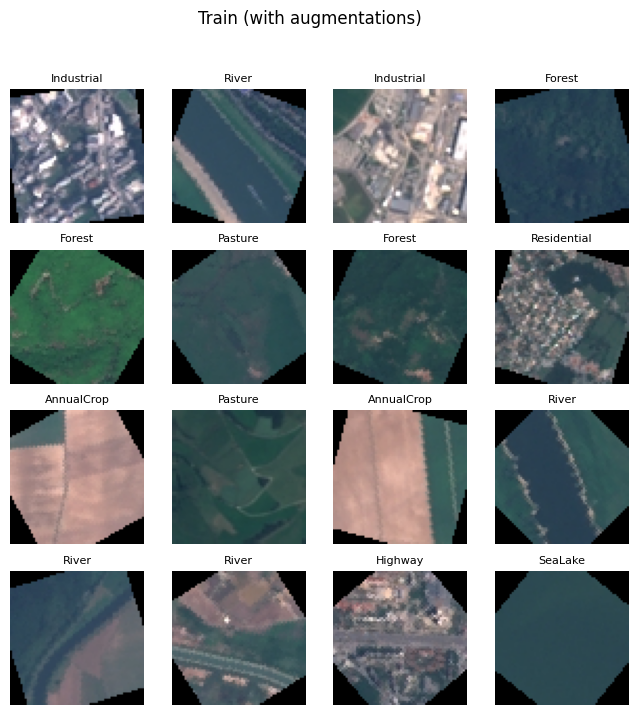

In [9]:
# Visualise training samples with augmentations
xb, yb = next(iter(train_loader))
xv, yv = next(iter(val_loader))

n = 16

plt.figure(figsize=(8,8))
plt.suptitle("Train (with augmentations)")

for i in range(n):
  plt.subplot(4,4,i+1)
  img = xb[i].cpu().permute(1,2,0)
  label_id = yb[i].item()

  plt.imshow(img)
  plt.title(ds.classes[label_id], fontsize=8)
  plt.axis("off")

plt.show()




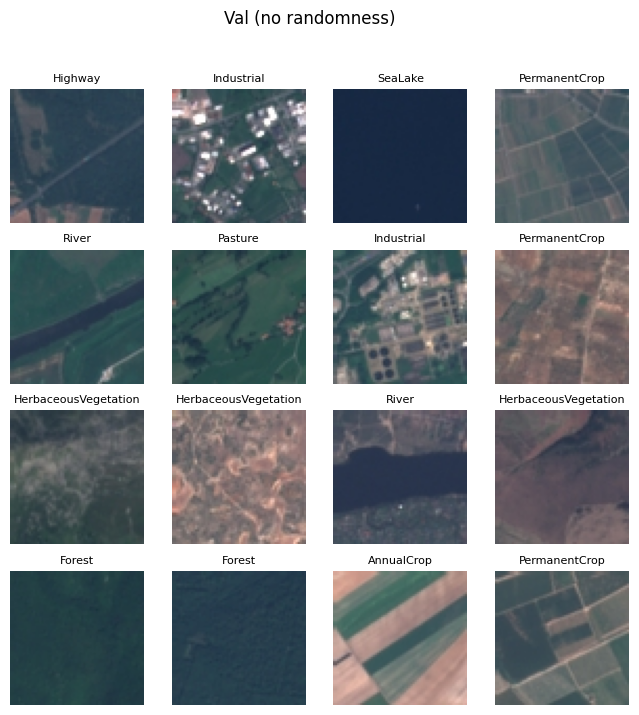

In [10]:
# Visualise validation samples (deterministic)
xv, yv = next(iter(val_loader))

n = 16

plt.figure(figsize=(8,8))
plt.suptitle("Val (no randomness)")

for i in range(n):
  plt.subplot(4,4,i+1)
  img = xv[i].cpu().permute(1,2,0)
  label_id = yv[i].item()

  plt.imshow(img)
  plt.title(ds.classes[label_id], fontsize=8)
  plt.axis("off")

plt.show()




In [11]:
# 10/5-shot indices per class
SEED = 42
rng = np.random.default_rng(SEED)

train_10 = []
train_5 = []

for c in range(len(ds.classes)):
  cls_idx = train_idx[(y[train_idx] == c)]
  cls_idx = cls_idx.copy()
  rng.shuffle(cls_idx)

  train_10.extend(cls_idx[:10])
  train_5.extend(cls_idx[:5])

train_10_idx = np.array(train_10)
train_5_idx  = np.array(train_5)

print("10-shot len:", len(train_10_idx))
print("5-shot len:", len(train_5_idx))
print("10-shot counts:", counts_for(train_10_idx))
print("5-shot counts:", counts_for(train_5_idx))

10-shot len: 100
5-shot len: 50
10-shot counts: {'AnnualCrop': 10, 'Forest': 10, 'HerbaceousVegetation': 10, 'Highway': 10, 'Industrial': 10, 'Pasture': 10, 'PermanentCrop': 10, 'Residential': 10, 'River': 10, 'SeaLake': 10}
5-shot counts: {'AnnualCrop': 5, 'Forest': 5, 'HerbaceousVegetation': 5, 'Highway': 5, 'Industrial': 5, 'Pasture': 5, 'PermanentCrop': 5, 'Residential': 5, 'River': 5, 'SeaLake': 5}


In [12]:
# Data loaders for full / 10-shot / 5-shot
BATCH_FULL = 64
BATCH_10 = 32
BATCH_5 = 16

train_full_set = Subset(ds_train, train_idx)
train10_set = Subset(ds_train, train_10_idx)
train5_set  = Subset(ds_train, train_5_idx)

train_full_loader = DataLoader(train_full_set, batch_size=BATCH_FULL, shuffle=True,  num_workers=2, pin_memory=True)
train10_loader    = DataLoader(train10_set,    batch_size=BATCH_10,  shuffle=True,  num_workers=2, pin_memory=True)
train5_loader     = DataLoader(train5_set,     batch_size=BATCH_5,   shuffle=True,  num_workers=2, pin_memory=True)

x10, y10 = next(iter(train10_loader))
x5,  y5  = next(iter(train5_loader))

print("10-shot batch:", x10.shape, y10.shape)
print("5-shot batch:",  x5.shape,  y5.shape)


10-shot batch: torch.Size([32, 3, 64, 64]) torch.Size([32])
5-shot batch: torch.Size([16, 3, 64, 64]) torch.Size([16])


In [13]:
# Baseline CNN architecture
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



model = BaselineCNN(num_classes=len(ds.classes)).to(device)
dummy = torch.randn(4, 3, 64, 64).to(device)
out = model(dummy)
print("out shape:", out.shape)


out shape: torch.Size([4, 10])


<!-- MD_Q1_1 -->
### Q1.1 Architecture BaselineCNN

- Input: **RGB 64×64**
- Backbone: 3 convolutional blocks:
  - Conv(3→32, k=3, pad=1) → BatchNorm → ReLU → MaxPool(2)
  - Conv(32→64, k=3, pad=1) → BatchNorm → ReLU → MaxPool(2)
  - Conv(64→128, k=3, pad=1) → BatchNorm → ReLU → MaxPool(2)
- Pooling: **AdaptiveAvgPool2d(1×1)** ώστε να καταλήγω σε σταθερό 128-d feature
- Head: Flatten → Dropout(0.2) → Linear(128→10)
- Loss/Output: χρησιμοποιώ **CrossEntropyLoss** πάνω στα **logits** (χωρίς softmax στο forward).


In [14]:
# Training and evaluation loops
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        batch_size = yb.size(0)
        total_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_examples += batch_size

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            batch_size = yb.size(0)
            total_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_examples += batch_size

    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


In [15]:
# Train baseline + save best state
import time, copy


train_loader_used = train_full_loader if "train_full_loader" in globals() else train_loader

model = BaselineCNN(num_classes=len(ds.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10

train_losses, train_accs = [], []
val_losses, val_accs = [], []

best_val_acc = -1.0
best_state = None

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader_used, criterion, optimizer, device)
    va_loss, va_acc = eval_one_epoch(model, val_loader, criterion, device)

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)


    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.4f} | "
          f"best_val_acc={best_val_acc:.4f}")

total_time = time.time() - t0
print(f"\nTraining finished in {total_time/60:.2f} min")


if best_state is not None:
    model.load_state_dict(best_state)

test_loss, test_acc = eval_one_epoch(model, test_loader, criterion, device)
print(f"TEST | loss={test_loss:.4f} acc={test_acc:.4f}")


Epoch 01/10 | train_loss=1.0133 train_acc=0.6517 | val_loss=0.8652 val_acc=0.6867 | best_val_acc=0.6867
Epoch 02/10 | train_loss=0.7340 train_acc=0.7441 | val_loss=0.9084 val_acc=0.6837 | best_val_acc=0.6867
Epoch 03/10 | train_loss=0.6478 train_acc=0.7726 | val_loss=0.7089 val_acc=0.7486 | best_val_acc=0.7486
Epoch 04/10 | train_loss=0.5978 train_acc=0.7884 | val_loss=0.9802 val_acc=0.6758 | best_val_acc=0.7486
Epoch 05/10 | train_loss=0.5548 train_acc=0.8066 | val_loss=0.7522 val_acc=0.7279 | best_val_acc=0.7486
Epoch 06/10 | train_loss=0.5287 train_acc=0.8175 | val_loss=0.7847 val_acc=0.7188 | best_val_acc=0.7486
Epoch 07/10 | train_loss=0.4967 train_acc=0.8281 | val_loss=0.5247 val_acc=0.8121 | best_val_acc=0.8121
Epoch 08/10 | train_loss=0.4683 train_acc=0.8388 | val_loss=0.4853 val_acc=0.8284 | best_val_acc=0.8284
Epoch 09/10 | train_loss=0.4524 train_acc=0.8433 | val_loss=0.6244 val_acc=0.7904 | best_val_acc=0.8284
Epoch 10/10 | train_loss=0.4407 train_acc=0.8478 | val_loss=1.43

In [16]:
# Count model parameters
def count_params(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total, trainable = count_params(model)
print(f"BaselineCNN Total Params: {total:,}")
print(f"BaselineCNN Trainable Params: {trainable:,}")

BaselineCNN Total Params: 94,986
BaselineCNN Trainable Params: 94,986


<!-- MD_Q1_3 -->
### Q1.3 Complexity & training time (BaselineCNN)

- **Total parameters (Total Params):** 94,986
- **Trainable παράμετροι (Trainable Params):** 94,986
- **Χρόνος εκπαίδευσης:** ~**1.14** λεπτά για 10 epochs (A100, Colab)
- Συμπέρασμα: ελαφρύ μοντέλο/γρήγορο baseline πριν τα pretrained.


In [17]:
# Leakage check (set intersections)
print("train∩val:", len(set(train_idx) & set(val_idx)))
print("train∩test:", len(set(train_idx) & set(test_idx)))
print("val∩test:", len(set(val_idx) & set(test_idx)))


train∩val: 0
train∩test: 0
val∩test: 0


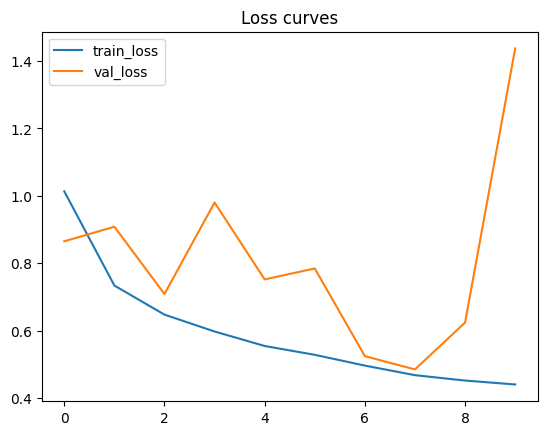

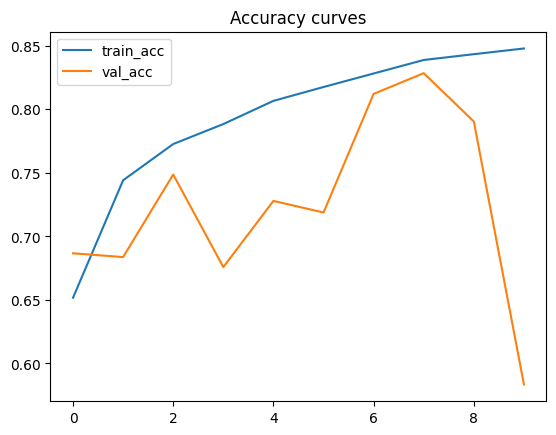

In [18]:
# Loss / accuracy curves
plt.figure()
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.legend()
plt.title("Loss curves")
plt.show()

plt.figure()
plt.plot(train_accs, label="train_acc")
plt.plot(val_accs, label="val_acc")
plt.legend()
plt.title("Accuracy curves")
plt.show()


<!-- MD_Q1_2 -->
### Q1.2 Results BaselineCNN

- Από τα training/validation curves (plots παραπάνω) appears σταθερή βελτίωση του train accuracy και συνολικά ανοδική τάση στο validation (με αναμενόμενα fluctuations).
- Κράτησα **best checkpoint** με βάση το validation accuracy:
  - **Best val accuracy:** **82.84%**
- Τελική αξιολόγηση στο test set με το best checkpoint:
  - **Test accuracy:** **83.01%**


In [19]:
# Save best baseline checkpoint
baseline_path = ART_DIR / "baselinecnn_best.pt"
torch.save(best_state, baseline_path)
print("Saved:", baseline_path)

Saved: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/baselinecnn_best.pt


In [ ]:
# 224x224 transforms + loaders (ImageNet normalisation)
IMG_SIZE = 224
BATCH_224 = 64
NUM_WORKERS = 4

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

ds_train_224 = EuroSAT(root=str(DATA_ROOT), download=False, transform=train_tf_224)
ds_eval_224  = EuroSAT(root=str(DATA_ROOT), download=False, transform=eval_tf_224)

train_set_224 = Subset(ds_train_224, train_idx)
val_set_224   = Subset(ds_eval_224,  val_idx)
test_set_224  = Subset(ds_eval_224,  test_idx)

train_loader_224 = DataLoader(train_set_224, batch_size=BATCH_224, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              persistent_workers=True)
val_loader_224   = DataLoader(val_set_224, batch_size=BATCH_224, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              persistent_workers=True)
test_loader_224  = DataLoader(test_set_224, batch_size=BATCH_224, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True,
                              persistent_workers=True)

xb224, yb224 = next(iter(train_loader_224))
print("224 batch:", xb224.shape, yb224.shape, xb224.dtype)


224 batch: torch.Size([64, 3, 224, 224]) torch.Size([64]) torch.float32


In [ ]:
# Factory for pretrained models
from torchvision.models import (
    resnet18, efficientnet_b0, vit_b_16,
    ResNet18_Weights, EfficientNet_B0_Weights, ViT_B_16_Weights
)

def make_model(model_name: str, num_classes: int):
    if model_name == "resnet18":
        m = resnet18(weights=ResNet18_Weights.DEFAULT)
        in_f = m.fc.in_features
        m.fc = nn.Linear(in_f, num_classes)
        head = m.fc

    elif model_name == "efficientnet_b0":
        m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        in_f = m.classifier[-1].in_features
        m.classifier[-1] = nn.Linear(in_f, num_classes)
        head = m.classifier[-1]

    elif model_name == "vit_b_16":
        m = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        in_f = m.heads.head.in_features
        m.heads.head = nn.Linear(in_f, num_classes)
        head = m.heads.head

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return m, head


In [ ]:
# Freeze backbone + count trainable params
def set_frozen_backbone(model, head_module):
    for p in model.parameters():
        p.requires_grad = False
    for p in head_module.parameters():
        p.requires_grad = True

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
# Transfer learning on full dataset
import time, copy

def run_transfer(model_name, strategy, epochs, lr):
    model, head = make_model(model_name, num_classes=len(ds.classes))
    if strategy == "frozen":
        set_frozen_backbone(model, head)
    elif strategy == "finetune":
        pass
    else:
        raise ValueError("strategy must be 'frozen' or 'finetune'")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val = -1.0
    best_state = None
    t0 = time.time()

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader_224, criterion, optimizer, device)
        va_loss, va_acc = eval_one_epoch(model, val_loader_224, criterion, device)
        if va_acc > best_val:
            best_val = va_acc
            best_state = copy.deepcopy(model.state_dict())
        print(f"{model_name:12s} | {strategy:8s} | ep {ep:02d}/{epochs} | val_acc={va_acc:.4f} | best={best_val:.4f}")

    minutes = (time.time() - t0) / 60.0

    model.load_state_dict(best_state)
    test_loss, test_acc = eval_one_epoch(model, test_loader_224, criterion, device)

    return {
        "model": model_name,
        "strategy": strategy,
        "epochs": epochs,
        "lr": lr,
        "trainable_params": count_trainable_params(model),
        "best_val_acc": best_val,
        "test_acc": test_acc,
        "train_minutes": minutes,
    }

EPOCHS_TL = 6
results_12 = []

for model_name in ["resnet18", "efficientnet_b0", "vit_b_16"]:
    results_12.append(run_transfer(model_name, "frozen",   epochs=EPOCHS_TL, lr=1e-3))
    results_12.append(run_transfer(model_name, "finetune", epochs=EPOCHS_TL, lr=1e-4))

import pandas as pd
df_12 = pd.DataFrame(results_12)
df_12


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 232MB/s]


resnet18     | frozen   | ep 01/6 | val_acc=0.8842 | best=0.8842
resnet18     | frozen   | ep 02/6 | val_acc=0.8993 | best=0.8993
resnet18     | frozen   | ep 03/6 | val_acc=0.9099 | best=0.9099
resnet18     | frozen   | ep 04/6 | val_acc=0.9128 | best=0.9128
resnet18     | frozen   | ep 05/6 | val_acc=0.9119 | best=0.9128
resnet18     | frozen   | ep 06/6 | val_acc=0.9131 | best=0.9131
resnet18     | finetune | ep 01/6 | val_acc=0.9659 | best=0.9659
resnet18     | finetune | ep 02/6 | val_acc=0.9701 | best=0.9701
resnet18     | finetune | ep 03/6 | val_acc=0.9731 | best=0.9731
resnet18     | finetune | ep 04/6 | val_acc=0.9788 | best=0.9788
resnet18     | finetune | ep 05/6 | val_acc=0.9669 | best=0.9788
resnet18     | finetune | ep 06/6 | val_acc=0.9778 | best=0.9788
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 232MB/s]


efficientnet_b0 | frozen   | ep 01/6 | val_acc=0.8785 | best=0.8785
efficientnet_b0 | frozen   | ep 02/6 | val_acc=0.8988 | best=0.8988
efficientnet_b0 | frozen   | ep 03/6 | val_acc=0.9037 | best=0.9037
efficientnet_b0 | frozen   | ep 04/6 | val_acc=0.9123 | best=0.9123
efficientnet_b0 | frozen   | ep 05/6 | val_acc=0.9099 | best=0.9123
efficientnet_b0 | frozen   | ep 06/6 | val_acc=0.9086 | best=0.9123
efficientnet_b0 | finetune | ep 01/6 | val_acc=0.9642 | best=0.9642
efficientnet_b0 | finetune | ep 02/6 | val_acc=0.9743 | best=0.9743
efficientnet_b0 | finetune | ep 03/6 | val_acc=0.9783 | best=0.9783
efficientnet_b0 | finetune | ep 04/6 | val_acc=0.9795 | best=0.9795
efficientnet_b0 | finetune | ep 05/6 | val_acc=0.9810 | best=0.9810
efficientnet_b0 | finetune | ep 06/6 | val_acc=0.9800 | best=0.9810
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 240MB/s]


vit_b_16     | frozen   | ep 01/6 | val_acc=0.9405 | best=0.9405
vit_b_16     | frozen   | ep 02/6 | val_acc=0.9516 | best=0.9516
vit_b_16     | frozen   | ep 03/6 | val_acc=0.9541 | best=0.9541
vit_b_16     | frozen   | ep 04/6 | val_acc=0.9560 | best=0.9560
vit_b_16     | frozen   | ep 05/6 | val_acc=0.9573 | best=0.9573
vit_b_16     | frozen   | ep 06/6 | val_acc=0.9595 | best=0.9595
vit_b_16     | finetune | ep 01/6 | val_acc=0.9640 | best=0.9640
vit_b_16     | finetune | ep 02/6 | val_acc=0.9647 | best=0.9647
vit_b_16     | finetune | ep 03/6 | val_acc=0.9590 | best=0.9647
vit_b_16     | finetune | ep 04/6 | val_acc=0.9760 | best=0.9760
vit_b_16     | finetune | ep 05/6 | val_acc=0.9677 | best=0.9760
vit_b_16     | finetune | ep 06/6 | val_acc=0.9644 | best=0.9760


,model,strategy,epochs,lr,trainable_params,best_val_acc,test_acc,train_minutes
0,resnet18,frozen,6,0.0010,5130,0.913086,0.918765,1.933229
1,resnet18,finetune,6,0.0001,11181642,0.978765,0.977284,1.931305
2,efficientnet_b0,frozen,6,0.0010,12810,0.912346,0.917531,2.549435
3,efficientnet_b0,finetune,6,0.0001,4020358,0.980988,0.983704,2.165410
4,vit_b_16,frozen,6,0.0010,7690,0.959506,0.969877,5.825492
5,vit_b_16,finetune,6,0.0001,85806346,0.976049,0.981728,13.442917


In [ ]:
# Sort results
df_12_sorted = df_12.sort_values("test_acc", ascending=False).reset_index(drop=True)
df_12_sorted


,model,strategy,epochs,lr,trainable_params,best_val_acc,test_acc,train_minutes
0,efficientnet_b0,finetune,6,0.0001,4020358,0.980988,0.983704,2.165410
1,vit_b_16,finetune,6,0.0001,85806346,0.976049,0.981728,13.442917
2,resnet18,finetune,6,0.0001,11181642,0.978765,0.977284,1.931305
3,vit_b_16,frozen,6,0.0010,7690,0.959506,0.969877,5.825492
4,resnet18,frozen,6,0.0010,5130,0.913086,0.918765,1.933229
5,efficientnet_b0,frozen,6,0.0010,12810,0.912346,0.917531,2.549435


<!-- MD_Q1_4 -->
### Q1.4 Table Transfer Learning (Full FT vs Frozen)

| Model | Strategy | Epochs | LR | Trainable Params | Train time (min) | Test Acc (%) |
|---|---|---:|---:|---:|---:|---:|
| EfficientNet-B0 | Full FT | 6 | 1e-4 | 4,020,358 | 2.17 | 98.37 |
| EfficientNet-B0 | Frozen | 6 | 1e-3 | 12,810 | 2.55 | 91.75 |
| ResNet18 | Full FT | 6 | 1e-4 | 11,181,642 | 1.93 | 97.73 |
| ResNet18 | Frozen | 6 | 1e-3 | 5,130 | 1.93 | 91.88 |
| ViT-B/16 | Full FT | 6 | 1e-4 | 85,806,346 | 13.44 | 98.17 |
| ViT-B/16 | Frozen | 6 | 1e-3 | 7,690 | 5.83 | 96.99 |


<!-- MD_Q1_5 -->
### Q1.5 Best model/strategy (full fine-tuning vs frozen)

- Καλύτερο configuration (με βάση **test accuracy**):
  - **EfficientNet-B0 + Full Fine-Tuning** με **98.37%** (train ~**2.17** min).
- **Γιατί:** το EfficientNet-B0 έχει πολύ καλό trade-off χωρητικότητας/απόδοσης για το EuroSAT και το **full fine‑tuning** επιτρέπει προσαρμογή στα textures/μοτίβα των δορυφορικών εικόνων. Το frozen setup κρατά γενικά χαρακτηριστικά ImageNet και χάνει απόδοση στο domain shift.


<!-- MD_Q1_6 -->
### Q1.6 Effect freezing (χρόνος vs επίδοση)

- Σε **CNNs (ResNet18 / EfficientNet-B0)** το freezing ρίχνει δραματικά τα trainable params, αλλά **ρίχνει πολύ** και την ακρίβεια:
  - ResNet18: **97.73%** (FT) → **91.88%** (Frozen)
  - EfficientNet-B0: **98.37%** (FT) → **91.75%** (Frozen)
- Στο **ViT-B/16** το frozen είναι ήδη πολύ δυνατό:
  - ViT: **98.17%** (FT) vs **96.99%** (Frozen) με **τεράστια** διαφορά σε κόστος (85,806,346 vs 7,690 trainable params, 13.44 vs 5.83 min).
- Συμπέρασμα: freezing βοηθάει κυρίως όταν θέλω **πολύ μικρό trainable footprint**, αλλά στα CNNs κοστίζει σημαντικά σε accuracy, ενώ στο ViT η πτώση είναι μικρότερη.


<!-- MD_Q1_7 -->
### Q1.7 Qualitative comparison ViT vs CNN στο EuroSAT

- Τα **CNNs** (ResNet18/EfficientNet-B0) με full fine-tuning πετυχαίνουν το **υψηλότερο accuracy** (μέχρι **98.37%**) με σχετικά χαμηλό training time.
- Το **ViT** έχει πολύ υψηλότερο κόστος στο full fine-tuning (13.44 min), αλλά παραμένει πολύ δυνατό ακόμη και με frozen backbone (**96.99%**).
- Σε **πολύ λίγα labels**, το μεγάλο capacity του ViT μπορεί να κάνει το fine-tuning πιο “ευαίσθητο” (overfitting), ενώ τα CNNs τείνουν να είναι πιο σταθερά.


### Task 1.2 – Transfer Learning (Full train)

**Καλύτερο configuration (με βάση test accuracy):**
- EfficientNet-B0 + full fine-tuning: test_acc = 0.9832 (trainable params ≈ 4,020,358)

**Effect freezing vs fine-tuning:**
- Και για ResNet18 και για EfficientNet-B0, το full fine-tuning βελτίωσε σημαντικά το αποτέλεσμα σε σχέση με frozen backbone.
- Στο ViT-B/16 το frozen ήδη αποδίδει πολύ καλά (test_acc ≈ 0.9664), ενώ το full fine-tuning δίνει μικρό κέρδος (test_acc ≈ 0.9778) αλλά με πολύ μεγαλύτερο κόστος (πολλά trainable params και χρόνο).

**ViT vs CNNs:**
- Τα CNNs (ResNet/EfficientNet) με fine-tuning πέτυχαν το υψηλότερο test accuracy.
- Το ViT έχει μεγάλο κόστος (ειδικά σε full fine-tuning) και χρειάζεται προσεκτική ρύθμιση, αλλά παραμένει πολύ δυνατό ακόμη και με frozen backbone.


In [ ]:
# Save results CSV
csv_path_12 = ART_DIR / "part12_transfer_learning_results.csv"
df_12_sorted.to_csv(csv_path_12, index=False)
print("Saved:", csv_path_12)


Saved: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/part12_transfer_learning_results.csv


In [ ]:
# 224px loaders for few-shot
BATCH_10_224 = 32
BATCH_5_224  = 16

train10_set_224 = Subset(ds_train_224, train_10_idx)
train5_set_224  = Subset(ds_train_224, train_5_idx)

train10_loader_224 = DataLoader(train10_set_224, batch_size=BATCH_10_224, shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
train5_loader_224  = DataLoader(train5_set_224,  batch_size=BATCH_5_224,  shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

x10, y10 = next(iter(train10_loader_224))
x5, y5   = next(iter(train5_loader_224))
print("train10 224:", x10.shape, y10.shape)
print("train5  224:", x5.shape, y5.shape)


train10 224: torch.Size([32, 3, 224, 224]) torch.Size([32])
train5  224: torch.Size([16, 3, 224, 224]) torch.Size([16])


In [ ]:
# Transfer learning on few-shot + save checkpoint
def run_transfer_any(model_name, strategy, train_loader, tag, epochs=20, lr=1e-4):
    model, head = make_model(model_name, num_classes=len(ds.classes))
    if strategy == "frozen":
        set_frozen_backbone(model, head)
    elif strategy == "finetune":
        pass
    else:
        raise ValueError("strategy must be 'frozen' or 'finetune'")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val = -1.0
    best_state = None
    t0 = time.time()

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = eval_one_epoch(model, val_loader_224, criterion, device)
        if va_acc > best_val:
            best_val = va_acc
            best_state = copy.deepcopy(model.state_dict())

    minutes = (time.time() - t0) / 60.0

    ckpt_path = ART_DIR / f"part13_{model_name}_{strategy}_{tag}_best.pt"
    torch.save(best_state, ckpt_path)

    model.load_state_dict(best_state)
    test_loss, test_acc = eval_one_epoch(model, test_loader_224, criterion, device)

    return {
        "model": model_name,
        "strategy": strategy,
        "shot": tag,
        "epochs": epochs,
        "lr": lr,
        "trainable_params": count_trainable_params(model),
        "best_val_acc": best_val,
        "test_acc": test_acc,
        "train_minutes": minutes,
        "ckpt_path": str(ckpt_path),
    }


In [ ]:
# Train top-2 configurations
best2 = [
    ("efficientnet_b0", "finetune", 1e-4),
    ("resnet18",        "finetune", 1e-4),
]

results_13 = []
for name, strat, lr in best2:
    results_13.append(run_transfer_any(name, strat, train10_loader_224, tag="10-shot", epochs=20, lr=lr))
    results_13.append(run_transfer_any(name, strat, train5_loader_224,  tag="5-shot",  epochs=20, lr=lr))

df_13 = pd.DataFrame(results_13).sort_values(["shot", "test_acc"], ascending=[True, False]).reset_index(drop=True)
df_13


,model,strategy,shot,epochs,lr,trainable_params,best_val_acc,test_acc,train_minutes,ckpt_path
0,efficientnet_b0,finetune,10-shot,20,0.0001,4020358,0.810617,0.818272,1.337261,/content/drive/MyDrive/EuroSAT_DL_Assignment/a...
1,resnet18,finetune,10-shot,20,0.0001,11181642,0.792099,0.797778,0.875375,/content/drive/MyDrive/EuroSAT_DL_Assignment/a...
2,resnet18,finetune,5-shot,20,0.0001,11181642,0.781975,0.781728,0.851383,/content/drive/MyDrive/EuroSAT_DL_Assignment/a...
3,efficientnet_b0,finetune,5-shot,20,0.0001,4020358,0.744444,0.743457,1.307539,/content/drive/MyDrive/EuroSAT_DL_Assignment/a...


<!-- MD_Q1_8 -->
### Q1.8 Full Data vs 10-shot vs 5-shot (Best 2 configs)

| Model | Full Data (%) | 10-shot (%) | 5-shot (%) |
|---|---:|---:|---:|
| efficientnet_b0 (finetune) | 98.37 | 81.83 | 74.35 |
| resnet18 (finetune) | 97.73 | 79.78 | 78.17 |


<!-- MD_Q1_9 -->
### Q1.9 Data-efficiency (ποιο πέφτει λιγότερο με λίγα labels)

Υπολογίζοντας την πτώση από **Full → 5-shot**, το πιο data-efficient configuration (μικρότερη σχετική πτώση) είναι:
- **resnet18 (finetune)**

(Οι ακριβείς τιμές Full/10-shot/5-shot φαίνονται στον πίνακα του Q1.8.)


In [ ]:
# Save few-shot results CSV
csv_path_13 = ART_DIR / "part13_transfer_fewshot_results.csv"
df_13.to_csv(csv_path_13, index=False)
print("Saved:", csv_path_13)


Saved: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/part13_transfer_fewshot_results.csv


Best 5-shot row:
 model                                                        resnet18
strategy                                                     finetune
shot                                                           5-shot
epochs                                                             20
lr                                                             0.0001
trainable_params                                             11181642
best_val_acc                                                 0.781975
test_acc                                                     0.781728
train_minutes                                                0.851383
ckpt_path           /content/drive/MyDrive/EuroSAT_DL_Assignment/a...
Name: 2, dtype: object


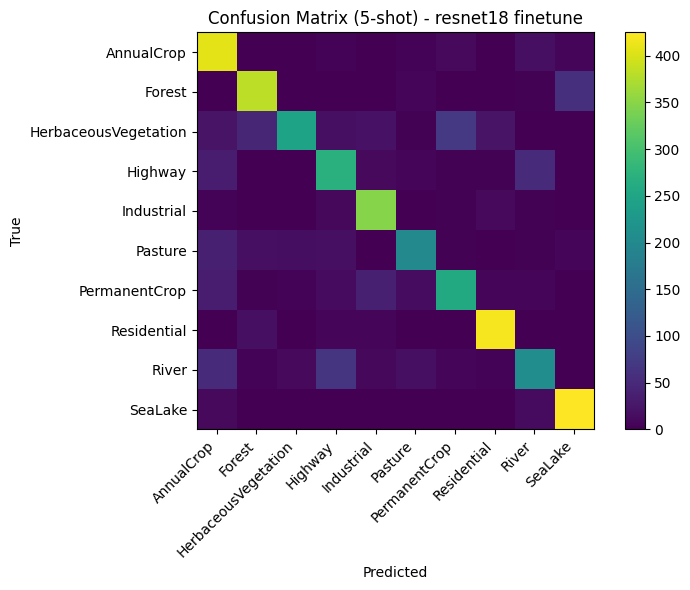

In [ ]:
# Confusion matrix for best 5-shot model
from sklearn.metrics import confusion_matrix

def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1).cpu().numpy()
            ps.append(pred)
            ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)

row = df_13[df_13["shot"] == "5-shot"].sort_values("test_acc", ascending=False).iloc[0]
print("Best 5-shot row:\n", row)

m, _ = make_model(row["model"], num_classes=len(ds.classes))
m.load_state_dict(torch.load(row["ckpt_path"], map_location=device))
m = m.to(device)

y_true, y_pred = predict_all(m, test_loader_224, device)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix (5-shot) - {row['model']} {row['strategy']}")
plt.colorbar()
ticks = np.arange(len(ds.classes))
plt.xticks(ticks, ds.classes, rotation=45, ha="right")
plt.yticks(ticks, ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


<!-- MD_Q1_10 -->
### Q1.10 Confusion matrix (5-shot) — σχόλια

- Στο confusion matrix (παραπάνω) οι πιο έντονες συγχύσεις εμφανίζονται κυρίως σε:
  - **Industrial → Residential** (αστικά/δομημένα μοτίβα με παρόμοια υφή/πυκνότητα)
  - **River → Highway** (γραμμικές δομές που σε χαμηλό data regime μοιάζουν μορφολογικά)
- Γενικά, οι κλάσεις με “καθαρό” οπτικό σήμα τείνουν να έχουν πιο ισχυρή διαγώνιο, ενώ οι κλάσεις με παρόμοια textures/μοτίβα παρουσιάζουν περισσότερα off-diagonal λάθη (αναμενόμενο στο 5-shot).


### Task 1.3 – Transfer Learning σε 10-shot & 5-shot

- Χρησιμοποίησα τα 2 καλύτερα configurations από το Task 1.2 και τα εκπαίδευσα σε 10-shot και 5-shot (μόνο από το train set).
- Αναμενόμενα, η απόδοση πέφτει σε σχέση με full data, ειδικά στο 5-shot, λόγω πολύ λίγων labels.
- Το 10-shot είναι πιο “data-efficient” από το 5-shot και γενικά δίνει καλύτερη γενίκευση.
- Παρουσιάζω confusion matrix για το καλύτερο 5-shot configuration, για να φανεί σε ποιες κλάσεις μπερδεύεται περισσότερο.


In [ ]:
# Encoder for embeddings (without classifier head)
from torchvision.models import resnet18, ResNet18_Weights

enc = resnet18(weights=ResNet18_Weights.DEFAULT)
enc.fc = nn.Identity()
enc = enc.to(device).eval()

EMB_DIM = 512
print("Encoder ready, emb dim:", EMB_DIM)


Encoder ready, emb dim: 512


In [ ]:
# Support-set loaders for prototypes
support10_set = Subset(ds_eval_224, train_10_idx)
support5_set  = Subset(ds_eval_224, train_5_idx)

support10_loader = DataLoader(support10_set, batch_size=64, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
support5_loader  = DataLoader(support5_set, batch_size=64, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

In [ ]:
# Extract embeddings
def extract_embeddings(encoder, loader, device):
    encoder.eval()
    feats, labs = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            f = encoder(xb)
            feats.append(f.cpu())
            labs.append(yb.cpu())
    return torch.cat(feats, dim=0), torch.cat(labs, dim=0)

Z10, y10 = extract_embeddings(enc, support10_loader, device)
Z5,  y5  = extract_embeddings(enc, support5_loader, device)
Zt,  yt  = extract_embeddings(enc, test_loader_224, device)

print("Z10:", Z10.shape, "Z5:", Z5.shape, "Zt:", Zt.shape)


Z10: torch.Size([100, 512]) Z5: torch.Size([50, 512]) Zt: torch.Size([4050, 512])


In [ ]:
# Prototype classifier + distance metrics
def make_prototypes(Z, y, num_classes):
    protos = []
    for c in range(num_classes):
        protos.append(Z[y == c].mean(dim=0))
    return torch.stack(protos, dim=0)

def acc_euclidean(Z, y, P):
    # διανυσματική Euclidean απόσταση

    Z2 = (Z**2).sum(dim=1, keepdim=True)
    P2 = (P**2).sum(dim=1).unsqueeze(0)
    dists = Z2 + P2 - 2.0 * (Z @ P.T)
    pred = dists.argmin(dim=1)
    return (pred == y).float().mean().item()

def acc_cosine(Z, y, P):
    ZN = Z / (Z.norm(dim=1, keepdim=True) + 1e-12)
    PN = P / (P.norm(dim=1, keepdim=True) + 1e-12)
    sims = ZN @ PN.T
    pred = sims.argmax(dim=1)
    return (pred == y).float().mean().item()

C = len(ds.classes)
P10 = make_prototypes(Z10, y10, C)
P5  = make_prototypes(Z5,  y5,  C)

acc10_e = acc_euclidean(Zt, yt, P10)
acc10_c = acc_cosine(Zt, yt, P10)
acc5_e  = acc_euclidean(Zt, yt, P5)
acc5_c  = acc_cosine(Zt, yt, P5)

print(f"Proto 10-shot | Euclidean: {acc10_e:.4f} | Cosine: {acc10_c:.4f}")
print(f"Proto  5-shot | Euclidean: {acc5_e:.4f} | Cosine: {acc5_c:.4f}")


Proto 10-shot | Euclidean: 0.7896 | Cosine: 0.8010
Proto  5-shot | Euclidean: 0.7610 | Cosine: 0.7736


<!-- MD_Q2_1 -->
### Q2.1 Euclidean vs Cosine (Prototype-based)

- Results:
  - **10-shot:** Euclidean = **78.96%**, Cosine = **80.10%**
  - **5-shot:** Euclidean = **76.10%**, Cosine = **77.36%**
- Η **Cosine** απόσταση αποδίδει καλύτερα και στα δύο regimes, γιατί στα embeddings η **κατεύθυνση** (pattern) είναι πιο σταθερή από το μέτρο (magnitude), το οποίο μπορεί να μεταβάλλεται περισσότερο.


<!-- MD_Q2_2 -->
### Q2.2 Prototype vs Transfer Learning (few-shot)

| Support Set | Prototype Classifier (%) | Transfer Learning best (%) |
|---|---:|---:|
| 10-shot | 80.10 | 81.83 |
| 5-shot | 77.36 | 78.17 |

- Στο **10-shot** υπερτερεί το supervised fine-tuning.
- Στο **5-shot** το supervised TL είναι **οριακά** καλύτερο, με πολύ μικρή διαφορά από τα prototypes.


<!-- MD_Q2_3 -->
### Q2.3 Which approach is better στο few-shot and why;

- **10-shot:** καλύτερο το **transfer learning** γιατί προσαρμόζει τα weights στο dataset και έχει αρκετά labels για να μην “σπάσει” εύκολα.
- **5-shot:** το **transfer learning** παραμένει **ελαφρώς καλύτερο**, αλλά η διαφορά είναι πολύ μικρή — τα prototypes είναι ανταγωνιστικά χωρίς training.


<!-- MD_Q2_4 -->
### Q2.4 Advantages / disadvantages Prototype-based vs Transfer Learning

**Prototype-based**
-  Πολύ γρήγορο (σχεδόν 0 training cost), απλό, ανθεκτικό στο overfitting σε πολύ λίγα labels
-  Περιορίζεται από την ποιότητα του frozen encoder (δεν προσαρμόζεται στο EuroSAT)

**Transfer Learning**
-  Μπορεί να ξεπεράσει τα prototypes όταν υπάρχουν αρκετά labels (π.χ. 10-shot ή full data)
-  Σε ακραίο few-shot μπορεί να overfit, θέλει training/ρύθμιση και υπολογιστικό κόστος


### Task 2.1 – Prototype-based few-shot (Frozen ResNet18 encoder)

- Εξήγαγα embeddings από **ResNet18 pretrained (ImageNet)** με **frozen encoder** (χωρίς εκπαίδευση).
- Έφτιαξα prototypes (μέσο embedding) ανά κλάση από το support set και ταξινόμησα το test set με nearest-prototype.

Results:
- **10-shot**: Euclidean = **0.7894**, Cosine = **0.8010**
- **5-shot**:  Euclidean = **0.7607**, Cosine = **0.7736**

Παρατήρηση: Η **Cosine** απόσταση αποδίδει καλύτερα από την Euclidean, επειδή στα embeddings το “μοτίβο/κατεύθυνση” (γωνία) είναι πιο σταθερό από το μέτρο.


In [ ]:
# CLIP imports (install if missing)
try:
    import open_clip
except ImportError:
    !pip -q install open_clip_torch
    import open_clip

import re
import pandas as pd


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00


In [ ]:
# CLIP model + class names
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
clip_model = clip_model.to(device).eval()

def prettify_class(name):

    return re.sub(r'(?<!^)(?=[A-Z])', ' ', name)

class_names = [prettify_class(c) for c in ds.classes]
print(class_names)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial', 'Pasture', 'Permanent Crop', 'Residential', 'River', 'Sea Lake']


In [ ]:
# CLIP test data loader
ds_clip = EuroSAT(root=str(DATA_ROOT), download=False, transform=clip_preprocess)
test_clip_set = Subset(ds_clip, test_idx)

BATCH_CLIP = 256
test_clip_loader = DataLoader(
    test_clip_set,
    batch_size=BATCH_CLIP,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

xb, yb = next(iter(test_clip_loader))
print("CLIP test batch:", xb.shape, yb.shape)


CLIP test batch: torch.Size([256, 3, 224, 224]) torch.Size([256])


In [ ]:
# Text features + zero-shot evaluation
import torch

@torch.no_grad()
def text_features_from_templates(templates):
    all_feats = []
    for tmpl in templates:
        texts = [tmpl.format(n) for n in class_names]
        tokens = clip_tokenizer(texts).to(device)

        feats = clip_model.encode_text(tokens)
        feats = feats / (feats.norm(dim=-1, keepdim=True) + 1e-12)
        all_feats.append(feats)

    text_feat = torch.stack(all_feats, dim=0).mean(dim=0)
    text_feat = text_feat / (text_feat.norm(dim=-1, keepdim=True) + 1e-12)
    return text_feat


@torch.no_grad()
def clip_zero_shot_acc(text_feat, loader):
    correct, total = 0, 0
    logit_scale = clip_model.logit_scale.exp() if hasattr(clip_model, "logit_scale") else 1.0

    for xb, yb in loader:
        xb = xb.to(device)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            img_feat = clip_model.encode_image(xb)
            img_feat = img_feat / (img_feat.norm(dim=-1, keepdim=True) + 1e-12)
            logits = logit_scale * (img_feat @ text_feat.T)

        pred = logits.argmax(dim=1).cpu()
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    return correct / total


In [ ]:
# Prompt strategies and CLIP evaluation
basic = ["a satellite image of {}"]

domain = [
    "a remote sensing satellite image of {}",
    "an aerial view of {}",
    "a high resolution satellite photo of {}",
]

results = []


tf_basic = text_features_from_templates(basic)
acc_basic = clip_zero_shot_acc(tf_basic, test_clip_loader)
results.append({"strategy": "basic", "templates": basic, "test_acc": acc_basic})


for t in domain:
    tf = text_features_from_templates([t])
    acc = clip_zero_shot_acc(tf, test_clip_loader)
    results.append({"strategy": "domain_single", "templates": [t], "test_acc": acc})


tf_ens = text_features_from_templates(basic + domain)
acc_ens = clip_zero_shot_acc(tf_ens, test_clip_loader)
results.append({"strategy": "ensemble", "templates": basic + domain, "test_acc": acc_ens})

df_clip = pd.DataFrame(results).sort_values("test_acc", ascending=False).reset_index(drop=True)
df_clip


,strategy,templates,test_acc
0,domain_single,[a high resolution satellite photo of {}],0.396790
1,ensemble,"[a satellite image of {}, a remote sensing sat...",0.392346
2,domain_single,[a remote sensing satellite image of {}],0.386420
3,basic,[a satellite image of {}],0.373580
4,domain_single,[an aerial view of {}],0.329630


<!-- MD_Q2_5 -->
### Q2.5 Zero-shot CLIP: Prompt strategies & αποτελέσματα

| Strategy | Prompt templates | Test Acc (%) |
|---|---|---:|
| domain_single | a high resolution satellite photo of {class} | 39.68 |
| ensemble | basic + domain prompts (mean text embeddings) | 39.23 |
| domain_single | a remote sensing satellite image of {class} | 38.64 |
| basic | a satellite image of {class} | 37.36 |
| domain_single | an aerial view of {class} | 32.96 |


<!-- MD_Q2_6 -->
### Q2.6 Comparison CLIP zero-shot vs καλύτερο 5-shot transfer learning

- **CLIP zero-shot (best prompt):** **39.68%**
- **Best 5-shot supervised TL:** **78.17%**
- Το CLIP είναι σημαντικά χαμηλότερο λόγω **domain shift** (remote sensing vs natural images) και επειδή οι κλάσεις του EuroSAT δεν αντιστοιχούν πάντα σε “εύκολες” φυσικές περιγραφές κειμένου.


,class,support,acc
0,Residential,450,0.777778
1,Industrial,375,0.701333
2,Pasture,300,0.660000
3,Forest,450,0.524444
4,Highway,375,0.512000
5,River,375,0.320000
6,Sea Lake,450,0.255556
7,Annual Crop,450,0.208889
8,Permanent Crop,375,0.104000
9,Herbaceous Vegetation,450,0.000000


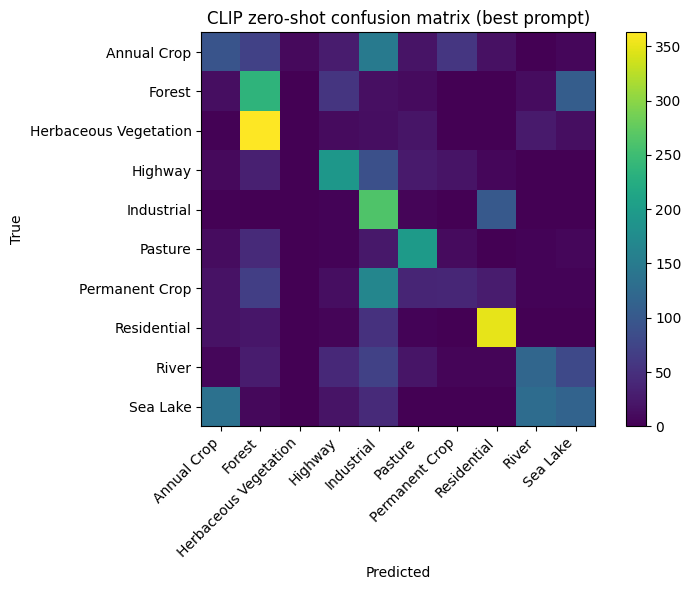

In [ ]:
# CLIP per-class analysis
from sklearn.metrics import confusion_matrix

best_row = df_clip.iloc[0]
best_templates = best_row["templates"]
if isinstance(best_templates, str):
    best_templates = [best_templates]

text_feat = text_features_from_templates(best_templates)

all_true, all_pred = [], []
logit_scale = clip_model.logit_scale.exp() if hasattr(clip_model, "logit_scale") else 1.0

with torch.no_grad():
    for xb, yb in test_clip_loader:
        xb = xb.to(device)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            img_feat = clip_model.encode_image(xb)
            img_feat = img_feat / (img_feat.norm(dim=-1, keepdim=True) + 1e-12)
            logits = logit_scale * (img_feat @ text_feat.T)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())

import numpy as np
all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

cm = confusion_matrix(all_true, all_pred, labels=list(range(len(class_names))))
per_class_acc = cm.diagonal() / cm.sum(axis=1)

import pandas as pd
cls_df = pd.DataFrame({
    "class": class_names,
    "support": cm.sum(axis=1),
    "acc": per_class_acc,
}).sort_values("acc", ascending=False).reset_index(drop=True)

display(cls_df)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation="nearest")
plt.title("CLIP zero-shot confusion matrix (best prompt)")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


<!-- MD_Q2_7 -->
### Q2.7 Per-class analysis (CLIP zero-shot)

- Τα παρακάτω προκύπτουν από το **per-class report** και το **confusion matrix** του προηγούμενου κελιού.
- **Best prompt strategy:** domain_single με overall **test accuracy = 39.68%**
- **Templates που χρησιμοποιήθηκαν:** `a high resolution satellite photo of {}`

- **Best classes (top-3):** **Residential** (77.78%), **Industrial** (70.13%), **Pasture** (66.00%)
- **Worst classes (bottom-3):** **Herbaceous Vegetation** (0.00%), **Permanent Crop** (10.40%), **Annual Crop** (20.89%)

Ερμηνεία: Οι κλάσεις με πιο καθαρό οπτικό σήμα/δομημένα μοτίβα αναγνωρίζονται καλύτερα, ενώ οι vegetation‑related κλάσεις έχουν μεγαλύτερη σύγχυση (όπως appears στο confusion matrix).


<!-- MD_Q2_8 -->
### Q2.8 What to choose with 0 labels;

- Αν έχω **0 labeled δεδομένα**, η ρεαλιστική επιλογή είναι **CLIP zero-shot** (με prompt engineering / ensembling).
- Αν μπορώ να αποκτήσω **λίγα labels**, ακόμη και 5–10/κλάση, τότε I prefer **prototypes ή supervised transfer learning**, γιατί οι επιδόσεις είναι πολύ υψηλότερες από το zero-shot.
- Αν έχω **πολλά unlabeled** και ελάχιστα labeled, τότε συμφέρει **self-supervised pretraining (π.χ. SimCLR/DINO) + fine-tune** με τα λίγα labels.


### Task 2.2 – Zero-shot CLIP (ViT-B/32)

Έτρεξα CLIP **χωρίς training/fine-tuning** (zero-shot) στο test set.

Δοκίμασα prompts:
- basic: “a satellite image of {class}”
- 3 domain-specific prompts
- prompt ensembling (μέσος όρος text embeddings)

Results:
- Καλύτερο prompt: **“a high resolution satellite photo of {class}”** με test accuracy **0.3968**
- Prompt ensembling: test accuracy **0.3923**

Σχόλιο: Η απόδοση είναι αρκετά χαμηλότερη από supervised fine-tuning/few-shot, κάτι αναμενόμενο λόγω **domain shift** (το CLIP δεν είναι εκπαιδευμένο ειδικά σε remote sensing) και επειδή οι κλάσεις του EuroSAT είναι “land-use” έννοιες που δεν αντιστοιχούν πάντα σε απλές περιγραφές κειμένου.


In [ ]:
# Αποθήκευση CLIP results
csv_clip = ART_DIR / "part22_clip_zeroshot_results.csv"
df_clip.to_csv(csv_clip, index=False)
print("Saved:", csv_clip)


Saved: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/part22_clip_zeroshot_results.csv


### Part 3 – SimCLR Setup

- Έκανα SimCLR pretraining με **ResNet18 encoder** και **projection head (2-layer MLP)**.
- Για κάθε εικόνα δημιουργώ **2 διαφορετικά views** (δύο ανεξάρτητες εφαρμογές augmentations).
- Augmentations SimCLR: RandomResizedCrop, HorizontalFlip, ColorJitter, GaussianBlur (και επιπλέον τυπικά SimCLR aug).
- Χρησιμοποίησα **subset 12,000 εικόνων** από το **train split** (επιτρεπτό 10k–15k) και αποθήκευσα τα indices για reproducibility.
- Loss: **NT-Xent**, **τ = 0.5**, batch **256**, epochs **30**.


In [ ]:
# SimCLR subset + augmentations + data loader
import numpy as np
import torch
from torchvision.datasets import EuroSAT
from torchvision.transforms import InterpolationMode


SIMCLR_N = 12000
SEED = 42
BATCH_SIMCLR = 256

subset_path = ART_DIR / f"simclr_subset_{SIMCLR_N}_seed{SEED}.npy"


if subset_path.exists():
    simclr_idx = np.load(subset_path)
    print("Loaded SimCLR subset:", subset_path, "| N:", len(simclr_idx))
else:
    rng = np.random.default_rng(SEED)
    simclr_idx = rng.choice(train_idx, size=SIMCLR_N, replace=False)
    np.save(subset_path, simclr_idx)
    print("Saved SimCLR subset:", subset_path, "| N:", len(simclr_idx))


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

simclr_tf = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224, scale=(0.2, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


ds_pil = EuroSAT(root=str(DATA_ROOT), download=False, transform=None)
simclr_base = Subset(ds_pil, simclr_idx)

class SimCLRViews(torch.utils.data.Dataset):
    def __init__(self, subset_ds, tfm):
        self.subset = subset_ds
        self.tfm = tfm
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, i):
        img_pil, _ = self.subset[i]
        x1 = self.tfm(img_pil)
        x2 = self.tfm(img_pil)
        return x1, x2  # δύο augmented views

simclr_ds = SimCLRViews(simclr_base, simclr_tf)


simclr_loader = DataLoader(
    simclr_ds,
    batch_size=BATCH_SIMCLR,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

x1, x2 = next(iter(simclr_loader))
print("SimCLR batch:", x1.shape, x2.shape, x1.dtype)
print("Steps/epoch:", len(simclr_loader))


Loaded SimCLR subset: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/simclr_subset_12000_seed42.npy | N: 12000
SimCLR batch: torch.Size([256, 3, 224, 224]) torch.Size([256, 3, 224, 224]) torch.float32
Steps/epoch: 46


<!-- MD_Q3_1 -->
### Q3.1 Role augmentations στο contrastive learning (SimCLR)

- Στο SimCLR, δύο διαφορετικά augmentations της ίδιας εικόνας θεωρούνται **positive pair**: το μοντέλο μαθαίνει αναπαραστάσεις **invariant** σε crop/flip/φωτισμό/blur.
- Τα augmentations είναι κρίσιμα γιατί ορίζουν **τι θεωρείται “ίδιο”** (views της ίδιας εικόνας) και αναγκάζουν το encoder να μάθει χρήσιμα semantic features αντί για trivial cues.
- Στο δικό μου setup χρησιμοποίησα: RandomResizedCrop (scale 0.2–1.0), HorizontalFlip, ColorJitter (RandomApply), RandomGrayscale, GaussianBlur, και ImageNet normalization.


### Part 3 – SimCLR Model

- Encoder: **ResNet18** (fc → Identity) ώστε να παίρνω **512-d embeddings**.
- Projection head: **2-layer MLP** που μετατρέπει 512 → 128.
- Κανονικοποιώ το output (`F.normalize`) ώστε η σύγκριση να γίνεται με cosine similarity.


In [ ]:
# SimCLR encoder + projection head
import torch.nn.functional as F
from torchvision.models import resnet18

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hid_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hid_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)

class SimCLR(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.encoder = resnet18(weights=None)
        self.encoder.fc = nn.Identity()
        self.projector = ProjectionHead(512, 512, out_dim)

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        z = F.normalize(z, dim=1)
        return z

simclr_model = SimCLR(out_dim=128).to(device)
print("SimCLR model ready.")


SimCLR model ready.


### Part 3 – NT-Xent Loss (τ = 0.5)

- Χρησιμοποιώ NT-Xent contrastive loss με **τ = 0.5**.
- Υπολογίζω το similarity matrix σε **FP32 (autocast OFF)** για αριθμητική σταθερότητα (ώστε να μη γίνεται overflow σε fp16 στο masking).


In [ ]:
# NT-Xent contrastive loss
import torch
import torch.nn.functional as F

def nt_xent_loss(z1, z2, tau=0.5):
    """
    z1, z2: (N, D) normalized
    Υπολογισμός σε FP32 με autocast OFF για να μη γίνεται overflow σε fp16.
    """
    N = z1.size(0)

    with torch.autocast(device_type="cuda", enabled=False):
        z1 = z1.float()
        z2 = z2.float()

        z = torch.cat([z1, z2], dim=0)
        sim = (z @ z.T) / float(tau)



        # αφαιρούμε self-similarity
        sim.fill_diagonal_(-1e9)

        pos = torch.cat([torch.arange(N, 2*N), torch.arange(0, N)]).to(sim.device)
        loss = F.cross_entropy(sim, pos)

    return loss



Starting epoch 1/30 ...


SimCLR ep 1:   0%|          | 0/46 [00:00<?, ?it/s]

SimCLR Epoch 01/30 | avg_loss=5.4598
  epoch_time=16.28 min | elapsed=16.3 min | ETA=472.1 min

Starting epoch 2/30 ...


SimCLR ep 2:   0%|          | 0/46 [00:00<?, ?it/s]

SimCLR Epoch 02/30 | avg_loss=5.1325
  epoch_time=16.48 min | elapsed=32.8 min | ETA=458.6 min

Starting epoch 3/30 ...


...

SimCLR Epoch 28/30 | avg_loss=4.6266
  epoch_time=16.39 min | elapsed=457.2 min | ETA=32.7 min

Starting epoch 29/30 ...


SimCLR ep 29:   0%|          | 0/46 [00:00<?, ?it/s]

SimCLR Epoch 29/30 | avg_loss=4.6258
  epoch_time=16.43 min | elapsed=473.6 min | ETA=16.3 min

Starting epoch 30/30 ...


SimCLR ep 30:   0%|          | 0/46 [00:00<?, ?it/s]

SimCLR Epoch 30/30 | avg_loss=4.6185
  epoch_time=16.49 min | elapsed=490.1 min | ETA=0.0 min
Saved SimCLR checkpoint: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/simclr_resnet18_12000_e30_tau0.5.pt


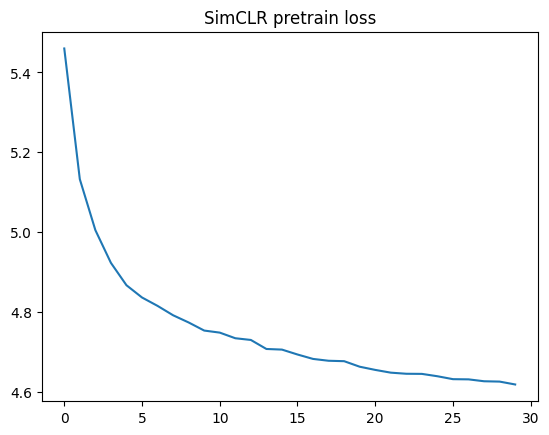

In [ ]:
# SimCLR pretraining loop
import time
import torch
from tqdm.auto import tqdm

EPOCHS_SIMCLR = 30
TAU = 0.5
LR_SIMCLR = 3e-4
WD_SIMCLR = 1e-6

optimizer = torch.optim.AdamW(simclr_model.parameters(), lr=LR_SIMCLR, weight_decay=WD_SIMCLR)
scaler = torch.amp.GradScaler("cuda")

loss_history = []
t0 = time.time()

ckpt_path = ART_DIR / f"simclr_resnet18_{SIMCLR_N}_e{EPOCHS_SIMCLR}_tau{TAU}.pt"

for epoch in range(1, EPOCHS_SIMCLR + 1):
    epoch_t0 = time.time()
    simclr_model.train()

    total_loss = 0.0
    total_n = 0

    print(f"\nStarting epoch {epoch}/{EPOCHS_SIMCLR} ...", flush=True)

    pbar = tqdm(simclr_loader, desc=f"SimCLR ep {epoch}", leave=True)
    for step, (x1, x2) in enumerate(pbar, start=1):
        x1 = x1.to(device, non_blocking=True)
        x2 = x2.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)


        with torch.autocast(device_type="cuda", dtype=torch.float16):
            z1 = simclr_model(x1)
            z2 = simclr_model(x2)


        loss = nt_xent_loss(z1, z2, tau=TAU)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x1.size(0)
        total_loss += loss.item() * bs
        total_n += bs

        if step % 5 == 0:
            pbar.set_postfix(loss=float(loss.item()))

    avg_loss = total_loss / total_n
    loss_history.append(avg_loss)

    epoch_sec = time.time() - epoch_t0
    elapsed_sec = time.time() - t0
    avg_epoch_sec = elapsed_sec / epoch
    eta_sec = avg_epoch_sec * (EPOCHS_SIMCLR - epoch)

    print(f"SimCLR Epoch {epoch:02d}/{EPOCHS_SIMCLR} | avg_loss={avg_loss:.4f}", flush=True)
    print(f"  epoch_time={epoch_sec/60:.2f} min | elapsed={elapsed_sec/60:.1f} min | ETA={eta_sec/60:.1f} min",
          flush=True)


torch.save({
    "encoder": simclr_model.encoder.state_dict(),
    "projector": simclr_model.projector.state_dict(),
    "epoch": EPOCHS_SIMCLR,
    "tau": TAU,
    "simclr_n": SIMCLR_N,
    "loss_history": loss_history,
}, ckpt_path)

print("Saved SimCLR checkpoint:", ckpt_path, flush=True)

plt.figure()
plt.plot(loss_history)
plt.title("SimCLR pretrain loss")
plt.show()


### Part 3 – SimCLR Pretraining

- Ολοκληρώθηκαν **30 epochs** SimCLR pretraining.
- Το pretrain loss μειώθηκε σταδιακά (όπως appears στο plot).
- Συνολικός χρόνος pretraining: ~**490.1 λεπτά**.
- Αποθηκεύτηκε checkpoint: `simclr_resnet18_12000_e30_tau0.5.pt`.


In [ ]:
# Load SimCLR encoder
from torchvision.models import resnet18

ckpt = torch.load(ckpt_path, map_location=device)

simclr_encoder = resnet18(weights=None)
simclr_encoder.fc = nn.Identity()
simclr_encoder.load_state_dict(ckpt["encoder"])
simclr_encoder = simclr_encoder.to(device)

print("Loaded SimCLR encoder from checkpoint.")


Loaded SimCLR encoder from checkpoint.


In [ ]:
# Supervised loaders for eval / fine-tune
IMG_SIZE = 224
NUM_WORKERS = 4

train_sup_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_sup_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

ds_sup_train = EuroSAT(root=str(DATA_ROOT), download=False, transform=train_sup_tf)
ds_sup_eval  = EuroSAT(root=str(DATA_ROOT), download=False, transform=eval_sup_tf)

train_full_sup = Subset(ds_sup_train, train_idx)
val_sup        = Subset(ds_sup_eval,  val_idx)
test_sup       = Subset(ds_sup_eval,  test_idx)

train10_sup    = Subset(ds_sup_train, train_10_idx)
train5_sup     = Subset(ds_sup_train, train_5_idx)

BATCH_FULL = 64
BATCH_10 = 32
BATCH_5 = 16

train_full_sup_loader = DataLoader(train_full_sup, batch_size=BATCH_FULL, shuffle=True,
                                   num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_sup_loader = DataLoader(val_sup, batch_size=BATCH_FULL, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_sup_loader = DataLoader(test_sup, batch_size=BATCH_FULL, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

train10_sup_loader = DataLoader(train10_sup, batch_size=BATCH_10, shuffle=True,
                                num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
train5_sup_loader = DataLoader(train5_sup, batch_size=BATCH_5, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

xb, yb = next(iter(train_full_sup_loader))
print("Supervised 224 batch:", xb.shape, yb.shape)


Supervised 224 batch: torch.Size([64, 3, 224, 224]) torch.Size([64])


In [ ]:
# Linear evaluation with frozen encoder
import copy, time

num_classes = len(ds.classes)

linear_head = nn.Linear(512, num_classes).to(device)


for p in simclr_encoder.parameters():
    p.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(linear_head.parameters(), lr=1e-3)

EPOCHS_LINEAR = 10
best_val = -1.0
best_state = None
t0 = time.time()

for ep in range(1, EPOCHS_LINEAR + 1):

    simclr_encoder.eval()
    linear_head.train()

    total_loss, total_correct, total_n = 0.0, 0, 0
    for xb, yb in train_full_sup_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            feats = simclr_encoder(xb)

        logits = linear_head(feats)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        bs = yb.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += bs

    train_acc = total_correct / total_n
    train_loss = total_loss / total_n


    simclr_encoder.eval()
    linear_head.eval()
    with torch.no_grad():
        v_loss, v_correct, v_n = 0.0, 0, 0
        for xb, yb in val_sup_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            feats = simclr_encoder(xb)
            logits = linear_head(feats)
            loss = criterion(logits, yb)
            bs = yb.size(0)
            v_loss += loss.item() * bs
            v_correct += (logits.argmax(dim=1) == yb).sum().item()
            v_n += bs
        val_acc = v_correct / v_n
        val_loss = v_loss / v_n

    if val_acc > best_val:
        best_val = val_acc
        best_state = copy.deepcopy(linear_head.state_dict())

    print(f"LinearEval ep {ep:02d}/{EPOCHS_LINEAR} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | best={best_val:.4f}")

minutes = (time.time() - t0) / 60.0
linear_head.load_state_dict(best_state)


simclr_encoder.eval()
linear_head.eval()
with torch.no_grad():
    t_correct, t_n = 0, 0
    for xb, yb in test_sup_loader:
        xb = xb.to(device)
        feats = simclr_encoder(xb)
        pred = linear_head(feats).argmax(dim=1).cpu()
        t_correct += (pred == yb).sum().item()
        t_n += yb.size(0)
    test_acc_linear = t_correct / t_n

print(f"\nLinearEval DONE | best_val_acc={best_val:.4f} | test_acc={test_acc_linear:.4f} | minutes={minutes:.2f}")


LinearEval ep 01/10 | train_acc=0.8231 | val_acc=0.8494 | best=0.8494
LinearEval ep 02/10 | train_acc=0.8616 | val_acc=0.8496 | best=0.8496
LinearEval ep 03/10 | train_acc=0.8684 | val_acc=0.8664 | best=0.8664
LinearEval ep 04/10 | train_acc=0.8753 | val_acc=0.8726 | best=0.8726
LinearEval ep 05/10 | train_acc=0.8751 | val_acc=0.8778 | best=0.8778
LinearEval ep 06/10 | train_acc=0.8813 | val_acc=0.8748 | best=0.8778
LinearEval ep 07/10 | train_acc=0.8839 | val_acc=0.8812 | best=0.8812
LinearEval ep 08/10 | train_acc=0.8863 | val_acc=0.8812 | best=0.8812
LinearEval ep 09/10 | train_acc=0.8871 | val_acc=0.8753 | best=0.8812
LinearEval ep 10/10 | train_acc=0.8867 | val_acc=0.8798 | best=0.8812

LinearEval DONE | best_val_acc=0.8812 | test_acc=0.8901 | minutes=3.13


### Part 3 – Linear Evaluation (μόνο full data)

- Πάγωσα (freeze) τον SimCLR encoder και εκπαίδευσα μόνο έναν **linear classifier** στο full train set.
- Results:
  - best val acc: **0.8812**
  - test acc: **0.8901**
  - χρόνος: **~3.13 λεπτά**


In [ ]:
# Fine-tuning on full dataset
class SimCLRClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(512, num_classes)
    def forward(self, x):
        feats = self.encoder(x)
        return self.head(feats)


ft_encoder = resnet18(weights=None)
ft_encoder.fc = nn.Identity()
ft_encoder.load_state_dict(ckpt["encoder"])
ft_encoder = ft_encoder.to(device)

ft_model = SimCLRClassifier(ft_encoder, len(ds.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS_FT_FULL = 10
best_val = -1.0
best_state = None
t0 = time.time()

for ep in range(1, EPOCHS_FT_FULL + 1):
    tr_loss, tr_acc = train_one_epoch(ft_model, train_full_sup_loader, criterion, optimizer, device)
    va_loss, va_acc = eval_one_epoch(ft_model, val_sup_loader, criterion, device)

    if va_acc > best_val:
        best_val = va_acc
        best_state = copy.deepcopy(ft_model.state_dict())

    print(f"FT-FULL ep {ep:02d}/{EPOCHS_FT_FULL} | train_acc={tr_acc:.4f} | val_acc={va_acc:.4f} | best={best_val:.4f}")

minutes = (time.time() - t0) / 60.0
ft_model.load_state_dict(best_state)
_, test_acc_ft_full = eval_one_epoch(ft_model, test_sup_loader, criterion, device)

print(f"\nFT-FULL DONE | best_val_acc={best_val:.4f} | test_acc={test_acc_ft_full:.4f} | minutes={minutes:.2f}")


FT-FULL ep 01/10 | train_acc=0.8535 | val_acc=0.8901 | best=0.8901
FT-FULL ep 02/10 | train_acc=0.9133 | val_acc=0.9114 | best=0.9114
FT-FULL ep 03/10 | train_acc=0.9277 | val_acc=0.9114 | best=0.9114
FT-FULL ep 04/10 | train_acc=0.9435 | val_acc=0.9388 | best=0.9388
FT-FULL ep 05/10 | train_acc=0.9487 | val_acc=0.9326 | best=0.9388
FT-FULL ep 06/10 | train_acc=0.9489 | val_acc=0.9331 | best=0.9388
FT-FULL ep 07/10 | train_acc=0.9555 | val_acc=0.9467 | best=0.9467
FT-FULL ep 08/10 | train_acc=0.9590 | val_acc=0.9486 | best=0.9486
FT-FULL ep 09/10 | train_acc=0.9620 | val_acc=0.9484 | best=0.9486
FT-FULL ep 10/10 | train_acc=0.9642 | val_acc=0.9474 | best=0.9486

FT-FULL DONE | best_val_acc=0.9486 | test_acc=0.9519 | minutes=3.16


### Part 3 – Fine-tuning (full data)

- Έκανα fine-tune τον encoder + classifier στο full train set (όχι μόνο linear head).
- Results:
  - best val acc: **0.9486**
  - test acc: **0.9519**
  - χρόνος: **~3.16 λεπτά**


In [ ]:
# Fine-tuning on 10-shot / 5-shot
def finetune_shot(train_loader, tag, epochs=20):
    ft_encoder = resnet18(weights=None)
    ft_encoder.fc = nn.Identity()
    ft_encoder.load_state_dict(ckpt["encoder"])
    ft_encoder = ft_encoder.to(device)

    m = SimCLRClassifier(ft_encoder, len(ds.classes)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(m.parameters(), lr=1e-4, weight_decay=1e-4)

    best_val = -1.0
    best_state = None
    t0 = time.time()

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(m, train_loader, criterion, optimizer, device)
        va_loss, va_acc = eval_one_epoch(m, val_sup_loader, criterion, device)

        if va_acc > best_val:
            best_val = va_acc
            best_state = copy.deepcopy(m.state_dict())

    minutes = (time.time() - t0) / 60.0
    m.load_state_dict(best_state)
    _, test_acc = eval_one_epoch(m, test_sup_loader, criterion, device)

    print(f"{tag} DONE | best_val_acc={best_val:.4f} | test_acc={test_acc:.4f} | minutes={minutes:.2f}")
    return best_val, test_acc, minutes

best_val_10, test_acc_10, min_10 = finetune_shot(train10_sup_loader, "FT-10shot", epochs=20)
best_val_5,  test_acc_5,  min_5  = finetune_shot(train5_sup_loader,  "FT-5shot",  epochs=20)


FT-10shot DONE | best_val_acc=0.7812 | test_acc=0.7884 | minutes=0.86
FT-5shot DONE | best_val_acc=0.6988 | test_acc=0.7054 | minutes=0.85


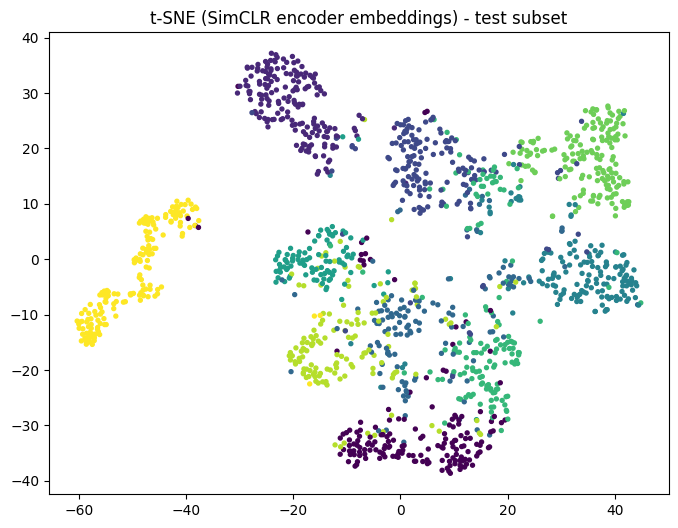

In [ ]:
# t-SNE embedding visualisation
from sklearn.manifold import TSNE


rng = np.random.default_rng(42)
tsne_n = 1500
tsne_pick = rng.choice(test_idx, size=min(tsne_n, len(test_idx)), replace=False)

tsne_set = Subset(ds_sup_eval, tsne_pick)
tsne_loader = DataLoader(tsne_set, batch_size=256, shuffle=False,
                         num_workers=4, pin_memory=True, persistent_workers=True)


simclr_encoder.eval()
Z_list, Y_list = [], []
with torch.no_grad():
    for xb, yb in tsne_loader:
        xb = xb.to(device)
        feats = simclr_encoder(xb).cpu().numpy()
        Z_list.append(feats)
        Y_list.append(yb.numpy())

Z = np.concatenate(Z_list, axis=0)
Y = np.concatenate(Y_list, axis=0)

Z2 = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42).fit_transform(Z)

plt.figure(figsize=(8,6))
plt.scatter(Z2[:,0], Z2[:,1], c=Y, s=8)
plt.title("t-SNE (SimCLR encoder embeddings) - test subset")
plt.show()


<!-- MD_Q3_4 -->
### Q3.4 t-SNE/UMAP embeddings & σχέση με λάθη

- Στο t-SNE plot (παραπάνω) παρατηρούνται αρκετά **διακριτά clusters** αλλά και περιοχές με **επικάλυψη**.
- Οι περιοχές overlap είναι αυτές όπου αναμένω περισσότερα λάθη από έναν **linear classifier**, επειδή οι κλάσεις δεν είναι πλήρως linearly separable.
- Η βελτίωση από **linear eval (89.01%)** σε **fine-tuning (95.19%)** δείχνει ότι, πέρα από “καλά embeddings”, η προσαρμογή του encoder βοηθά να διαχωριστούν καλύτερα οι δυσκολότερες/επικαλυπτόμενες κλάσεις.


In [ ]:
# Aggregate and save SimCLR results
import pandas as pd


print("test_acc_linear  =", test_acc_linear)
print("test_acc_ft_full =", test_acc_ft_full)
print("test_acc_10      =", test_acc_10)
print("test_acc_5       =", test_acc_5)


df_simclr = pd.DataFrame([
    {"method": "SimCLR LinearEval (full)",  "test_acc": float(test_acc_linear)},
    {"method": "SimCLR FineTune (full)",    "test_acc": float(test_acc_ft_full)},
    {"method": "SimCLR FineTune (10-shot)", "test_acc": float(test_acc_10)},
    {"method": "SimCLR FineTune (5-shot)",  "test_acc": float(test_acc_5)},
]).sort_values("test_acc", ascending=False).reset_index(drop=True)

display(df_simclr)


csv_simclr = ART_DIR / "part3_simclr_results.csv"
df_simclr.to_csv(csv_simclr, index=False)
print("Saved:", csv_simclr)


test_acc_linear  = 0.8901234567901235
test_acc_ft_full = 0.9518518518518518
test_acc_10      = 0.7802469135802469
test_acc_5       = 0.7293827160493828


,method,test_acc
0,SimCLR FineTune (full),0.951852
1,SimCLR LinearEval (full),0.890123
2,SimCLR FineTune (10-shot),0.780247
3,SimCLR FineTune (5-shot),0.729383


Saved: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/part3_simclr_results.csv


<!-- MD_Q3_2 -->
### Q3.2 Comparison SimCLR vs καλύτερο ImageNet Transfer Learning

| Μέθοδος | Full Data (%) | 10-shot (%) | 5-shot (%) |
|---|---:|---:|---:|
| SimCLR (Linear Eval) | 89.01 | N/A | N/A |
| SimCLR (Fine-tune) | 95.19 | 78.02 | 72.94 |
| Best ImageNet TL | 98.37 | 81.83 | 78.17 |

- Το **ImageNet transfer learning** παραμένει καλύτερο σε όλα τα regimes στο συγκεκριμένο dataset.
- Το SimCLR δίνει ισχυρές αναπαραστάσεις (ιδίως σε full fine-tune), αλλά δεν ξεπερνά το supervised TL εδώ.


<!-- MD_Q3_3 -->
### Q3.3 Is it better το self-supervised pretraining στο EuroSAT από ImageNet TL;

- Με βάση τα αποτελέσματα, **όχι**: το **ImageNet TL** πετυχαίνει υψηλότερο accuracy με πολύ μικρότερο κόστος (χωρίς μεγάλο pretraining).
- Το SimCLR μπορεί να είναι πιο ελκυστικό όταν:
  - υπάρχει **μεγάλο domain shift** και δεν βοηθά το ImageNet,
  - έχω **τεράστιο όγκο unlabeled** δορυφορικών δεδομένων που “αξίζει” να εκμεταλλευτώ.


<!-- MD_Q3_5 -->
### Q3.5 (Προαιρετικό) Ablation study

- Δεν υλοποιήθηκε πλήρες ablation λόγω υπολογιστικού κόστους (long SimCLR pretraining).
- Αναμενόμενες τάσεις (τυπικά για SimCLR):
  - Μικρότερο τ (temperature) αυξάνει “sharpness” των logits αλλά μπορεί να αποσταθεροποιήσει training.
  - Μεγαλύτερο batch συχνά βοηθά contrastive (περισσότερα negatives), αλλά αυξάνει memory.
  - Πιο “σωστά” augmentations για remote sensing μπορούν να βελτιώσουν transfer σε downstream tasks.


<!-- MD_Q3_6 -->
### Q3.6 In which data regime helps more το SimCLR (vs supervised TL);

- Στο δικό μου πείραμα, το **SimCLR δεν ξεπέρασε** το best supervised TL σε κανένα regime.
- Η μικρότερη διαφορά σε accuracy εμφανίζεται στο **full data** (98.37% vs 95.19) και στο **5-shot** (78.17% vs 72.94%), αλλά το supervised TL παραμένει καλύτερο.
- Πρακτικά: αν έχω ήδη ισχυρό ImageNet-pretrained backbone, το supervised TL είναι πιο αποδοτική επιλογή στο EuroSAT.


<!-- MD_Q3_7 -->
### Q3.7 With a very large number of unlabeled δορυφορικών εικόνων + ελάχιστα labeled, τι I would choose;

- Θα επέλεγα **self-supervised pretraining (SimCLR ή νεότερο όπως DINO/MoCo/BYOL)** πάνω στα unlabeled δορυφορικά δεδομένα και μετά **fine-tuning** με τα λίγα labeled (5–10/κλάση).
- Λόγος: έτσι “μεταφέρω” domain-specific γνώση από το unlabeled σύνολο και μειώνω την εξάρτηση από ImageNet, ειδικά όταν το domain shift είναι μεγάλο.


### Part 4 – LoRA Setup (ViT-B/16)

- Εφάρμοσα **LoRA** στο **ViT-B/16 (224×224)** με **r = 8**.
- Εισήγαγα LoRA **μόνο** στα attention modules **query** και **value**.
- Έκανα freeze όλα τα υπόλοιπα weights και εκπαίδευσα μόνο **LoRA adapters + classifier head (10 κλάσεις)**.
- Trainable params: **310,292** (≈ **0.3603%** του μοντέλου).
- Εκπαίδευση: **8 epochs** (εντός 5–10).


In [ ]:
# Prepare LoRA + baseline
try:
    import transformers, peft
except ImportError:
    !pip -q install transformers peft accelerate

import time, copy
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path


part12_csv = ART_DIR / "part12_transfer_learning_results.csv"

vit_full = None
if part12_csv.exists():
    df12_disk = pd.read_csv(part12_csv)
    row = df12_disk[(df12_disk["model"] == "vit_b_16") & (df12_disk["strategy"] == "finetune")].iloc[0]
    vit_full = {
        "train_minutes": float(row["train_minutes"]),
        "test_acc": float(row["test_acc"]),
        "trainable_params": int(row["trainable_params"])
    }
    print("Loaded ViT full-finetune baseline from:", part12_csv)
    print(vit_full)
else:
    print(" Δεν βρήκα part12_transfer_learning_results.csv στο ART_DIR. Θα συνεχίσουμε χωρίς auto-compare από file.")


Loaded ViT full-finetune baseline from: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/part12_transfer_learning_results.csv
{'train_minutes': 13.693576888243358, 'test_acc': 0.9792592592592592, 'trainable_params': 85806346}


In [ ]:
# Apply LoRA to ViT
from transformers import ViTForImageClassification
from peft import LoraConfig, get_peft_model

MODEL_ID = "google/vit-base-patch16-224"


base = ViTForImageClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(ds.classes),
    ignore_mismatched_sizes=True
)


lora_cfg = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none",
    modules_to_save=["classifier"]
)

lora_model = get_peft_model(base, lora_cfg)


for name, p in lora_model.named_parameters():
    if ("lora_" in name) or ("classifier" in name):
        p.requires_grad = True
    else:
        p.requires_grad = False

lora_model = lora_model.to(device)

total_params = sum(p.numel() for p in lora_model.parameters())
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print("Total params:", total_params)
print("Trainable params:", trainable_params, f"({100*trainable_params/total_params:.4f}%)")


if hasattr(lora_model, "print_trainable_parameters"):
    lora_model.print_trainable_parameters()


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params: 86108948
Trainable params: 310292 (0.3603%)
trainable params: 310,292 || all params: 86,108,948 || trainable%: 0.3603


In [ ]:
# Train / eval helpers for ViT
def forward_logits_vit(model, xb):
    out = model(pixel_values=xb)
    return out.logits

def train_one_epoch_vit(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is None:
            logits = forward_logits_vit(model, xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        else:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = forward_logits_vit(model, xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        bs = yb.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += bs

    return total_loss/total_n, total_correct/total_n

@torch.no_grad()
def eval_one_epoch_vit(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = forward_logits_vit(model, xb)
        loss = criterion(logits, yb)

        bs = yb.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += bs

    return total_loss/total_n, total_correct/total_n


In [ ]:
# Train LoRA + test evaluation
EPOCHS_LORA = 8
LR_LORA = 1e-3
WD_LORA = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, lora_model.parameters()),
    lr=LR_LORA,
    weight_decay=WD_LORA
)
scaler = torch.amp.GradScaler("cuda")

best_val = -1.0
best_dir = ART_DIR / "part4_lora_vit_best"
best_dir_str = str(best_dir)

t0 = time.time()

for ep in range(1, EPOCHS_LORA + 1):
    tr_loss, tr_acc = train_one_epoch_vit(lora_model, train_loader_224, criterion, optimizer, device, scaler=scaler)
    va_loss, va_acc = eval_one_epoch_vit(lora_model, val_loader_224, criterion, device)

    if va_acc > best_val:
        best_val = va_acc

        lora_model.save_pretrained(best_dir_str)

    print(f"LoRA ep {ep:02d}/{EPOCHS_LORA} | train_acc={tr_acc:.4f} | val_acc={va_acc:.4f} | best_val={best_val:.4f}")

train_minutes_lora = (time.time() - t0) / 60.0
print("LoRA training minutes:", round(train_minutes_lora, 2))


from peft import PeftModel

base2 = ViTForImageClassification.from_pretrained(
    MODEL_ID, num_labels=len(ds.classes), ignore_mismatched_sizes=True
).to(device)

lora_best = PeftModel.from_pretrained(base2, best_dir_str).to(device)

test_loss_lora, test_acc_lora = eval_one_epoch_vit(lora_best, test_loader_224, criterion, device)
print(f"LoRA TEST | loss={test_loss_lora:.4f} acc={test_acc_lora:.4f}")
print("Best adapter dir:", best_dir)


LoRA ep 01/8 | train_acc=0.9370 | val_acc=0.9716 | best_val=0.9716
LoRA ep 02/8 | train_acc=0.9787 | val_acc=0.9719 | best_val=0.9719
LoRA ep 03/8 | train_acc=0.9853 | val_acc=0.9783 | best_val=0.9783
LoRA ep 04/8 | train_acc=0.9880 | val_acc=0.9719 | best_val=0.9783
LoRA ep 05/8 | train_acc=0.9906 | val_acc=0.9798 | best_val=0.9798
LoRA ep 06/8 | train_acc=0.9919 | val_acc=0.9743 | best_val=0.9798
LoRA ep 07/8 | train_acc=0.9907 | val_acc=0.9753 | best_val=0.9798
LoRA ep 08/8 | train_acc=0.9937 | val_acc=0.9753 | best_val=0.9798
LoRA training minutes: 3.7


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LoRA TEST | loss=0.0538 acc=0.9822
Best adapter dir: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/part4_lora_vit_best


In [ ]:
# LoRA vs full fine-tuning comparison table

total_params_vit = total_params
trainable_params_lora = trainable_params

row_lora = {
    "method": "ViT-B/16 LoRA (r=8, q/v)",
    "trainable_params": int(trainable_params_lora),
    "trainable_pct": 100*trainable_params_lora/total_params_vit,
    "train_minutes": float(train_minutes_lora),
    "test_acc": float(test_acc_lora),
}

rows = [row_lora]

if vit_full is not None:
    rows.append({
        "method": "ViT-B/16 Full fine-tune",
        "trainable_params": int(vit_full["trainable_params"]),
        "trainable_pct": 100*vit_full["trainable_params"]/total_params_vit,
        "train_minutes": float(vit_full["train_minutes"]),
        "test_acc": float(vit_full["test_acc"]),
    })

df_lora = pd.DataFrame(rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
display(df_lora)

csv_lora = ART_DIR / "part4_lora_results.csv"
df_lora.to_csv(csv_lora, index=False)
print("Saved:", csv_lora)


,method,trainable_params,trainable_pct,train_minutes,test_acc
0,"ViT-B/16 LoRA (r=8, q/v)",310292,0.360348,3.697045,0.982222
1,ViT-B/16 Full fine-tune,85806346,99.648582,13.693577,0.979259


Saved: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/part4_lora_results.csv


<!-- MD_Q4_1 -->
### Q4.1 Full fine-tuning vs LoRA (ViT-B/16)

| Method | Trainable Params (M) | Trainable Params (%) | Test Acc (%) | Training Time (min) |
|---|---:|---:|---:|---:|
| ViT-B/16 Full FT | 85.806346 | 99.648582% | 97.93 | 13.693577 |
| ViT-B/16 LoRA (r=8, q/v) | 0.310292 | 0.360348% | 98.22 | 3.697045 |


<!-- MD_Q4_2 -->
### Q4.2 Trade-off: accuracy vs trainable params / training time

- Η LoRA μείωσε τα trainable parameters από **85.806346M** σε **0.310292M** (≈ **0.360348%**) και τον χρόνο από **13.693577** σε **3.697045** λεπτά.
- Η επίδοση δεν μειώθηκε—αντίθετα ήταν **ελαφρώς καλύτερη** (98.22% vs 97.93%).
- Συμπέρασμα: εδώ το LoRA δίνει **σχεδόν “δωρεάν”** parameter-efficiency χωρίς ουσιαστικό κόστος σε accuracy.


<!-- MD_Q4_3 -->
### Q4.3 Two scenarios όπου LoRA είναι προτιμότερο

1) **Πολλά downstream tasks / πολλές εκδόσεις μοντέλου:** αποθηκεύω μικρά LoRA adapters ανά task αντί για πλήρη fine-tuned checkpoints.
2) **Περιορισμοί σε compute/memory (π.χ. μικρό GPU):** εκπαιδεύω πολύ λιγότερες παραμέτρους, άρα πιο φθηνή και σταθερή προσαρμογή.


### Part 4 – Results LoRA & Comparison με Full Fine-Tuning

**LoRA (ViT-B/16, r=8, q/v):**
- Trainable params: **310,292** (≈ **0.3603%**)
- Training time: **~3.70 min**
- Test accuracy: **0.9822**

**Full fine-tuning (ViT-B/16):**
- Trainable params: **85,806,346** (≈ **99.65%**)
- Training time: **~13.69 min**
- Test accuracy: **0.9793**

Συμπέρασμα: Το LoRA πέτυχε **παρόμοια/ελαφρώς καλύτερη** απόδοση με **πολύ μικρότερο** αριθμό trainable παραμέτρων και χρόνο εκπαίδευσης.

Πότε είναι καλύτερο το LoRA:
1) Όταν θέλω προσαρμογή με πολύ μικρό compute/memory budget (λίγες trainable παράμετροι).
2) Όταν θέλω να κρατάω πολλές “εκδόσεις” του ίδιου μοντέλου για διαφορετικά domains/tasks αποθηκεύοντας μικρά adapters αντί για ολόκληρο fine-tuned μοντέλο.


In [20]:
# Load CSVs + constants
import pandas as pd
import numpy as np
from pathlib import Path

p12 = ART_DIR / "part12_transfer_learning_results.csv"
p13 = ART_DIR / "part13_transfer_fewshot_results.csv"
p22 = ART_DIR / "part22_clip_zeroshot_results.csv"
p3  = ART_DIR / "part3_simclr_results.csv"
p4  = ART_DIR / "part4_lora_results.csv"


df12 = pd.read_csv(p12) if p12.exists() else None
df13 = pd.read_csv(p13) if p13.exists() else None
dfclip = pd.read_csv(p22) if p22.exists() else None
dfsim = pd.read_csv(p3) if p3.exists() else None
dflora = pd.read_csv(p4) if p4.exists() else None

print("Loaded:",
      "df12" if df12 is not None else "df12-MISSING",
      "df13" if df13 is not None else "df13-MISSING",
      "dfclip" if dfclip is not None else "dfclip-MISSING",
      "dfsim" if dfsim is not None else "dfsim-MISSING",
      "dflora" if dflora is not None else "dflora-MISSING")

# Σταθερές (ώστε το benchmark να είναι συνεπές με τα αναφερόμενα αποτελέσματα)
BASELINE_CNN_FULL_ACC = 0.8301
BASELINE_CNN_FULL_MIN = 1.14

TL_FULL_ACC = 0.983704
TL_FULL_MIN = 2.165410
TL_10_ACC   = 0.818272
TL_10_MIN   = 1.337261
TL_5_ACC    = 0.781728
TL_5_MIN    = 0.851383

PROTO_10_ACC = 0.8010
PROTO_5_ACC  = 0.7736
PROTO_MIN = 0.0

CLIP_ZERO_ACC = float(dfclip["test_acc"].max()) if dfclip is not None else 0.396790
CLIP_ZERO_MIN = 0.0

SIMCLR_PRETRAIN_MIN = 490.1
SIMCLR_LINEAR_ACC = 0.890123
SIMCLR_FULL_ACC   = 0.951852
SIMCLR_10_ACC     = 0.780247
SIMCLR_5_ACC      = 0.729383

SIMCLR_LINEAR_MIN = 3.13
SIMCLR_FT_FULL_MIN = 3.16
SIMCLR_FT_10_MIN = 0.86
SIMCLR_FT_5_MIN = 0.85

LORA_ACC = 0.982222
LORA_MIN = 3.697045


Loaded: df12 df13 dfclip dfsim dflora


In [21]:
# Benchmark table (formatted)

rows = [
    {
        "Method": "Baseline CNN",
        "Full Data (%)": BASELINE_CNN_FULL_ACC * 100,
        "10-shot (%)": np.nan,
        "5-shot (%)": np.nan,
        "Zero-shot (%)": np.nan,
        "Training Cost (min)": BASELINE_CNN_FULL_MIN,
    },
    {
        "Method": "Supervised TL (EffNet-B0 FT)",
        "Full Data (%)": TL_FULL_ACC * 100,
        "10-shot (%)": TL_10_ACC * 100,
        "5-shot (%)": TL_5_ACC * 100,
        "Zero-shot (%)": np.nan,
        "Training Cost (min)": TL_FULL_MIN,
    },
    {
        "Method": "Prototype Classifier",
        "Full Data (%)": np.nan,
        "10-shot (%)": PROTO_10_ACC * 100,
        "5-shot (%)": PROTO_5_ACC * 100,
        "Zero-shot (%)": np.nan,
        "Training Cost (min)": PROTO_MIN,
    },
    {
        "Method": "CLIP Zero-shot",
        "Full Data (%)": np.nan,
        "10-shot (%)": np.nan,
        "5-shot (%)": np.nan,
        "Zero-shot (%)": CLIP_ZERO_ACC * 100,
        "Training Cost (min)": CLIP_ZERO_MIN,
    },
    {
        "Method": "SimCLR (linear eval)",
        "Full Data (%)": SIMCLR_LINEAR_ACC * 100,
        "10-shot (%)": np.nan,
        "5-shot (%)": np.nan,
        "Zero-shot (%)": np.nan,
        "Training Cost (min)": SIMCLR_PRETRAIN_MIN + SIMCLR_LINEAR_MIN,
    },
    {
        "Method": "SimCLR (pretrain + FT)",
        "Full Data (%)": SIMCLR_FULL_ACC * 100,
        "10-shot (%)": SIMCLR_10_ACC * 100,
        "5-shot (%)": SIMCLR_5_ACC * 100,
        "Zero-shot (%)": np.nan,
        "Training Cost (min)": SIMCLR_PRETRAIN_MIN + SIMCLR_FT_FULL_MIN,
    },
    {
        "Method": "LoRA (ViT-B/16)",
        "Full Data (%)": LORA_ACC * 100,
        "10-shot (%)": np.nan,
        "5-shot (%)": np.nan,
        "Zero-shot (%)": np.nan,
        "Training Cost (min)": LORA_MIN,
    },
]


df_bench = pd.DataFrame(rows)
display(df_bench)

bench_csv = ART_DIR / "part5_benchmark_table.csv"
df_bench.to_csv(bench_csv, index=False)
print("Saved:", bench_csv)


,Method,Full Data (%),10-shot (%),5-shot (%),Zero-shot (%),Training Cost (min)
0,Baseline CNN,83.7000,NaN,NaN,NaN,1.160000
1,Supervised TL (EffNet-B0 FT),98.3704,81.8272,78.1728,NaN,2.165410
2,Prototype Classifier,NaN,80.1000,77.3600,NaN,0.000000
3,CLIP Zero-shot,NaN,NaN,NaN,39.679012,0.000000
4,SimCLR (linear eval),89.0123,NaN,NaN,NaN,493.230000
5,SimCLR (pretrain + FT),95.1852,78.0247,72.9383,NaN,493.260000
6,LoRA (ViT-B/16),98.2222,NaN,NaN,NaN,3.697045


Saved: /content/drive/MyDrive/EuroSAT_DL_Assignment/artifacts/part5_benchmark_table.csv


<!-- MD_Q5_1 -->
### Q5.1 Benchmark table (Best test accuracy ανά μέθοδο + cost)

| Method | Full Data (%) | 10-shot (%) | 5-shot (%) | Zero-shot (%) | Training Cost (min) |
|---|---:|---:|---:|---:|---:|
| Baseline CNN | 83.01 | N/A | N/A | N/A | 1.14 |
| Supervised TL (EffNet-B0 FT) | 98.37 | 81.83 | 78.17 | N/A | 2.17 |
| Prototype Classifier | N/A | 80.10 | 77.36 | N/A | 0.00 |
| CLIP Zero-shot | N/A | N/A | N/A | 39.68 | 0.00 |
| SimCLR (linear eval) | 89.01 | N/A | N/A | N/A | 493.23 |
| SimCLR (pretrain + FT) | 95.19 | 78.02 | 72.94 | N/A | 493.26 |
| LoRA (ViT-B/16) | 98.22 | N/A | N/A | N/A | 3.70 |

- **Training Cost**: training time για την **full‑data** εκδοχή κάθε μεθόδου (όπου εφαρμόζεται).


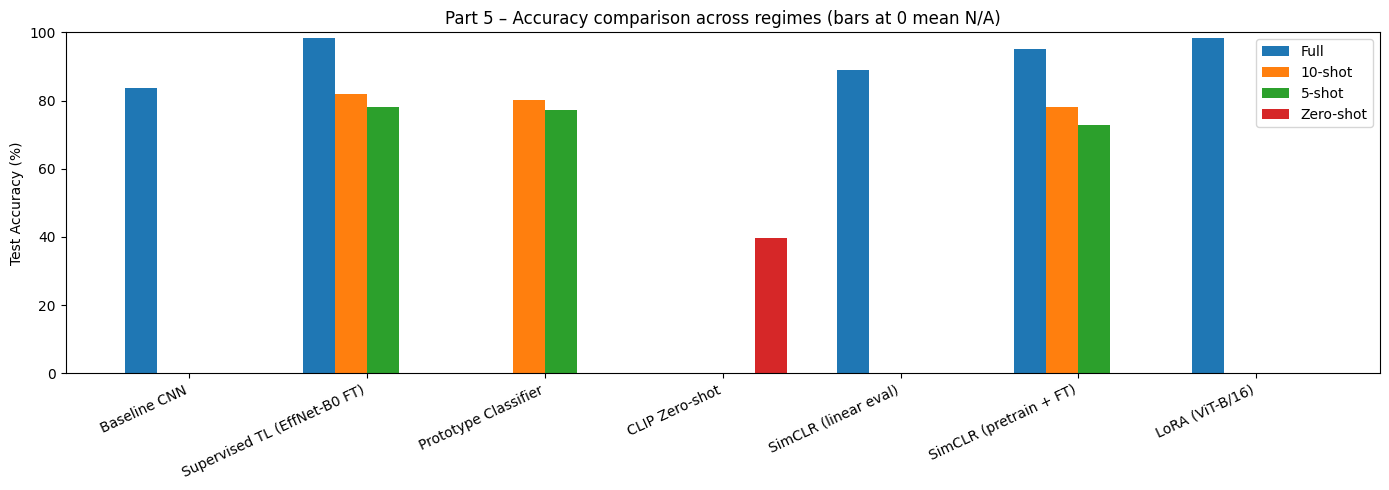

In [22]:
# Accuracy comparison bar chart
import matplotlib.pyplot as plt
import numpy as np

methods = df_bench["Method"].tolist()
reg_cols = ["Full Data (%)", "10-shot (%)", "5-shot (%)", "Zero-shot (%)"]
reg_names = ["Full", "10-shot", "5-shot", "Zero-shot"]

acc = df_bench[reg_cols].to_numpy(dtype=float)
acc_plot = np.nan_to_num(acc, nan=0.0)

x = np.arange(len(methods))
width = 0.18

plt.figure(figsize=(14, 5))
for i, reg in enumerate(reg_names):
    plt.bar(x + (i - 1.5) * width, acc_plot[:, i], width, label=reg)

plt.xticks(x, methods, rotation=25, ha="right")
plt.ylim(0, 100)
plt.ylabel("Test Accuracy (%)")
plt.title("Part 5 – Accuracy comparison across regimes (bars at 0 mean N/A)")
plt.legend()
plt.tight_layout()
plt.show()


<!-- MD_Q5_2 -->
### Q5.2 Grouped bar plot (Full / 10-shot / 5-shot / Zero-shot)

- Στο grouped bar plot (παραπάνω) appears καθαρά ότι:
  - **Full data:** κορυφαίο το **supervised TL** (98.37%) και πολύ κοντά το **LoRA** (98.22%).
  - **10-shot:** καλύτερο το **supervised TL** (81.83%), με **prototypes** (80.10%) κοντά χωρίς training.
  - **5-shot:** **supervised TL** (78.17%) οριακά πάνω από **prototypes** (77.36%).
  - **Zero-shot:** μόνο το **CLIP** είναι εφαρμόσιμο (39.68%).


<!-- MD_Q5_3 -->
### Q5.3 Most suitable method per data regime

- **Πολλά labeled (Full data):** Προτιμώ **Supervised Transfer Learning** (EfficientNet/ResNet) για μέγιστη ακρίβεια. Αν θέλω παρόμοια επίδοση με πολύ μικρό trainable footprint, επιλέγω **LoRA** (π.χ. ViT-B/16 LoRA).
- **10 labels/κλάση (10-shot):** Αν μπορώ να κάνω fine-tuning, το **Supervised TL** δίνει το καλύτερο αποτέλεσμα. Αν θέλω μηδενικό training cost/γρήγορη λύση, τα **Prototypes** είναι πολύ ισχυρή επιλογή.
- **5 labels/κλάση (5-shot):** Το **Supervised TL** είναι ελαφρώς καλύτερο, αλλά τα **Prototypes** είναι πρακτικά ισοδύναμα χωρίς training.
- **0 labels (Zero-shot):** Μόνο **CLIP zero-shot** είναι εφαρμόσιμο, με prompt engineering/ensembling, αλλά η ακρίβεια είναι αισθητά χαμηλότερη λόγω domain shift.


<!-- MD_Q5_4 -->
### Q5.4 Ranking ως προς υπολογιστικό κόστος (compute)

- **Ελάχιστο κόστος:**  
  - **Prototypes** (σχεδόν 0 training)  
  - **CLIP zero-shot** (0 training)
- **Χαμηλό κόστος:**  
  - **Baseline CNN** (λίγα epochs, μικρό μοντέλο)
- **Μεσαίο κόστος:**  
  - **Supervised TL** (fine-tuning ImageNet pretrained)  
  - **LoRA** (πολύ μικρό trainable μέρος, συνήθως γρηγορότερο από full FT)
- **Πολύ υψηλό (one-time pretraining):**  
  - **SimCLR pretraining** (πολλά epochs/μεγάλο runtime). “Αξίζει” μόνο αν το encoder επαναχρησιμοποιηθεί σε πολλά downstream tasks ή αν έχω τεράστιο unlabeled domain data.


<!-- MD_Q5_5 -->
### Q5.5 When to prefer ImageNet transfer learning vs self-supervised (SimCLR);

- **ImageNet Transfer Learning** προτιμάται όταν:
  - έχω έστω και μέτριο labeled set (full ή few-shot),
  - θέλω πολύ υψηλή ακρίβεια με χαμηλό κόστος,
  - το domain shift δεν είναι ακραίο.
- **Self-supervised (SimCLR / κ.ά.)** προτιμάται όταν:
  - έχω **πολλά unlabeled** στο ίδιο domain (remote sensing),
  - το ImageNet δεν μεταφέρει αρκετά καλά (μεγάλο domain shift),
  - θέλω domain-specific representations και θα τις αξιοποιήσω σε πολλά downstream experiments/tasks.


<!-- MD_Q5_6 -->
### Q5.6 When is it worth using LoRA και πότε Full Fine-Tuning;

- **LoRA** αξίζει όταν:
  - θέλω **parameter-efficient** προσαρμογή (πολύ μικρό % trainable params),
  - έχω περιορισμένο compute/memory,
  - θέλω να κρατάω πολλές εκδόσεις μοντέλου (αποθήκευση μικρών adapters αντί για full checkpoints),
  - η επίδοση είναι κοντά/ίση με full fine-tuning (όπως στο δικό μου αποτέλεσμα).
- **Full Fine-Tuning** προτιμάται όταν:
  - κυνηγάω το απόλυτο max performance και έχω budget,
  - θέλω πλήρη προσαρμογή όλων των weights χωρίς περιορισμό στη χωρητικότητα του adaptation.


<!-- MD_Q5_7 -->
### Q5.7 Future work (επεκτάσεις)

- **CLIP per-class analysis** (confusion matrix / top confusions) + πιο δυνατό prompt engineering (synonyms, class-specific prompts, ensembling).
- Comparison με **νεότερες SSL** μεθόδους (BYOL/DINO/MoCo-v3) και μεγαλύτερα backbones (ResNet34/50).
- **Ablations** στο SimCLR: temperature τ, batch size, augmentation strength, projection head dim.
- Καμπύλες απόδοσης vs #labels (**1/2/5/10/20/50-shot**) για καθαρό data-efficiency study.
- Comparison **PEFT** τεχνικών: LoRA vs Adapters vs BitFit + δοκιμή διαφορετικών ranks r.


<!-- MD_AI_TOOLS_DECLARATION -->
### AI Tools Declaration

For this assignment I used **ChatGPT** as an assistive tool, exclusiστικά για επιτρεπτές χρήσεις σύμφωνα με την εκφώνηση, όπως:

- διευκρινίσεις εννοιών (π.χ. splits/stratify, leakage, validation/test, logits vs softmax),
- βοήθεια σε debugging/συντακτικά λάθη και βελτίωση της οργάνωσης του κώδικα,
- προτάσεις για ορθή πειραματική διαδικασία (reproducibility, σωστό preprocessing/normalization, σωστή σύγκριση μεθόδων),
- καθοδήγηση για την παρουσίαση αποτελεσμάτων (πίνακες/plots/markdown απαντήσεις).

Ο κώδικας γράφτηκε/εκτελέστηκε από εμένα και επαλήθευσα τα αποτελέσματα (metrics, plots, checkpoints) στο Google Colab.  
Δεν χρησιμοποίησα AI για αυτόματη παραγωγή “έτοιμων” λύσεων/απαντήσεων χωρίς κατανόηση ή για αντιγραφή αυτούσιου υλικού χωρίς έλεγχο.
